In [ ]:
# =========================================================
# MODELING WORKFLOW FROM FINAL SITE-YEAR DATASET
# FAIR COMPARISON:
#   baseline  = climate + traits
#   deadwood  = climate + traits + deadwood + forestcoverloss
# CV = leave-one-site-out
# =========================================================

library(data.table)
library(dplyr)
library(ranger)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
# ---- either read from file ----
f <- "derived_tables/modelready_06Mar26_no_CRO_GRA_SNO_BSV.csv"

# read
dt <- fread(f)

# basic checks
cat("Original dimensions:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")
cat("Year range in raw data:", min(dt$year, na.rm = TRUE), "to", max(dt$year, na.rm = TRUE), "\n")



Original dimensions: 1689 rows x 194 cols
Year range in raw data: 1994 to 2024 


In [5]:
# keep only needed years
dt <- dt[year >= 2016 & year <= 2024]

# remove rows with missing site or year
dt <- dt[!is.na(SITE_ID) & !is.na(year)]

# make sure SITE_ID is character
dt[, SITE_ID := as.character(SITE_ID)]

# number of available years per site in 2016-2024
site_year_count <- dt[, .(
  n_years = uniqueN(year),
  years_available = paste(sort(unique(year)), collapse = ", ")
), by = SITE_ID]

# sites with at least 2 years
sites_2yr <- site_year_count[n_years >= 2, SITE_ID]

# sites with at least 3 years
sites_3yr <- site_year_count[n_years >= 3, SITE_ID]

# filtered datasets
dt_2yr <- dt[SITE_ID %in% sites_2yr]
dt_3yr <- dt[SITE_ID %in% sites_3yr]

# sort nicely
setorder(dt_2yr, SITE_ID, year)
setorder(dt_3yr, SITE_ID, year)

# print summary
cat("\nAfter filtering to 2016-2024:\n")
cat("Rows:", nrow(dt), "\n")
cat("Unique sites:", uniqueN(dt$SITE_ID), "\n")

cat("\n2-year dataset:\n")
cat("Sites:", uniqueN(dt_2yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_2yr), "\n")

cat("\n3-year dataset:\n")
cat("Sites:", uniqueN(dt_3yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_3yr), "\n")

# preview a few sites
cat("\nExample site-year counts:\n")
print(head(site_year_count[order(-n_years, SITE_ID)], 20))

# save outputs
fwrite(site_year_count, "site_year_count_2016_2024.csv")
fwrite(dt_2yr, "modeldata_sites_atleast_2years_2016_2024.csv")
fwrite(dt_3yr, "modeldata_sites_atleast_3years_2016_2024.csv")

cat("\nFiles written:\n")
cat("- site_year_count_2016_2024.csv\n")
cat("- modeldata_sites_atleast_2years_2016_2024.csv\n")
cat("- modeldata_sites_atleast_3years_2016_2024.csv\n")


After filtering to 2016-2024:
Rows: 701 
Unique sites: 142 

2-year dataset:
Sites: 119 
Rows : 678 

3-year dataset:
Sites: 108 
Rows : 656 

Example site-year counts:
    SITE_ID n_years                                      years_available
     <char>   <int>                                               <char>
 1:  IT-Ren       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 2:  US-BZB       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 3:  US-BZF       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 4:  US-ICh       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 5:  US-ICs       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 6:  US-Me6       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 7:  US-Ton       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 8:  US-Vcp       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 9:  US-Wjs       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
10:  CA-TPD       8       2

In [1]:
library(data.table)

# =========================================================
# STEP 2: Inspect columns and identify key variable groups
# =========================================================

# read the filtered 2-year dataset as reference
dt <- fread("derived_tables/modeldata_sites_atleast_2years_2016_2024.csv")

cat("Dimensions:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n\n")

# ---------------------------------------------------------
# 1) Print all column names
# ---------------------------------------------------------
cat("==== ALL COLUMN NAMES ====\n")
print(names(dt))

# ---------------------------------------------------------
# 2) Search for likely important groups of variables
# ---------------------------------------------------------
find_cols <- function(patterns, x) {
  pat <- paste(patterns, collapse = "|")
  grep(pat, x, value = TRUE, ignore.case = TRUE)
}

all_cols <- names(dt)

gs_cols       <- find_cols(c("grow", "season", "gs", "phen", "center", "centre", "doy"), all_cols)
efp_cols      <- find_cols(c("^uWUE$", "^ETmax$", "^GPPsat$", "^NEPmax$", "efp"), all_cols)
anom_cols     <- find_cols(c("anom", "anomaly"), all_cols)
trait_cols    <- find_cols(c("trait", "wood", "sla", "leaf", "height", "seed", "hydro", "root", "lt", "wd"), all_cols)
dead_cols     <- find_cols(c("dead", "mort"), all_cols)
forest_cols   <- find_cols(c("forest", "cover", "loss", "treecover"), all_cols)
meteo_cols    <- find_cols(c("tmp", "temp", "tair", "ta_", "vpd", "ppt", "prec", "rain", "rad", "rg", "rh", "sm", "soil", "mean", "upper", "lower", "q[0-9]"), all_cols)

cat("\n==== POSSIBLE GROWING SEASON COLUMNS ====\n")
print(gs_cols)

cat("\n==== POSSIBLE EFP COLUMNS ====\n")
print(efp_cols)

cat("\n==== POSSIBLE ANOMALY COLUMNS ====\n")
print(anom_cols)

cat("\n==== POSSIBLE TRAIT COLUMNS ====\n")
print(trait_cols)

cat("\n==== POSSIBLE DEADWOOD / MORTALITY COLUMNS ====\n")
print(dead_cols)

cat("\n==== POSSIBLE FOREST / COVER LOSS COLUMNS ====\n")
print(forest_cols)

cat("\n==== POSSIBLE METEO COLUMNS ====\n")
print(meteo_cols)

# ---------------------------------------------------------
# 3) Print a compact summary of columns with classes
# ---------------------------------------------------------
col_info <- data.table(
  column = names(dt),
  class  = sapply(dt, function(x) class(x)[1])
)

cat("\n==== COLUMN CLASSES ====\n")
print(col_info)

# ---------------------------------------------------------
# 4) Show first few rows of selected columns if they exist
# ---------------------------------------------------------
candidate_cols <- unique(c(
  "SITE_ID", "year", "Year",
  gs_cols, efp_cols, anom_cols, dead_cols, forest_cols
))

candidate_cols <- candidate_cols[candidate_cols %in% names(dt)]

cat("\n==== PREVIEW OF SELECTED COLUMNS ====\n")
print(dt[1:min(10, .N), ..candidate_cols])

# ---------------------------------------------------------
# 5) Save the inspection tables
# ---------------------------------------------------------
fwrite(col_info, "step2_column_classes.csv")

writeLines(names(dt), "step2_all_column_names.txt")
writeLines(gs_cols, "step2_possible_growing_season_cols.txt")
writeLines(efp_cols, "step2_possible_efp_cols.txt")
writeLines(anom_cols, "step2_possible_anomaly_cols.txt")
writeLines(trait_cols, "step2_possible_trait_cols.txt")
writeLines(dead_cols, "step2_possible_deadwood_cols.txt")
writeLines(forest_cols, "step2_possible_forest_cols.txt")
writeLines(meteo_cols, "step2_possible_meteo_cols.txt")

cat("\nFiles written:\n")
cat("- step2_column_classes.csv\n")
cat("- step2_all_column_names.txt\n")
cat("- step2_possible_growing_season_cols.txt\n")
cat("- step2_possible_efp_cols.txt\n")
cat("- step2_possible_anomaly_cols.txt\n")
cat("- step2_possible_trait_cols.txt\n")
cat("- step2_possible_deadwood_cols.txt\n")
cat("- step2_possible_forest_cols.txt\n")
cat("- step2_possible_meteo_cols.txt\n")

Dimensions: 678 rows x 194 cols

==== ALL COLUMN NAMES ====
  [1] "SITE_ID"                "year"                   "uWUE"                  
  [4] "ETmax"                  "precipAvail"            "Gavail"                
  [7] "GSmax"                  "CO2avail"               "G1"                    
 [10] "EF"                     "EFampl"                 "GPPsat"                
 [13] "NEPmax"                 "Rb"                     "Rbmax"                 
 [16] "aCUE"                   "TZ"                     "nyears"                
 [19] "LOCATION_LAT"           "LOCATION_LONG"          "LOCATION_ELEV"         
 [22] "IGBP"                   "P_mean_m01"             "P_mean_m02"            
 [25] "P_mean_m03"             "P_mean_m04"             "P_mean_m05"            
 [28] "P_mean_m06"             "P_mean_m07"             "P_mean_m08"            
 [31] "P_mean_m09"             "P_mean_m10"             "P_mean_m11"            
 [34] "P_mean_m12"             "P_q10_m01"       

In [8]:
library(data.table)

# =========================================================
# STEP 3: Calculate EFP anomalies using ALL available years
# =========================================================

dt <- fread("derived_tables/modelready_06Mar26_no_CRO_GRA_SNO_BSV.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# make sure sorted
setorder(dt, SITE_ID, year)

# EFP variables
efp_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 1) Site-level long-term means across ALL years
# ---------------------------------------------------------
for (v in efp_vars) {
  mean_name <- paste0(v, "_site_mean")
  dt[, (mean_name) := mean(get(v), na.rm = TRUE), by = SITE_ID]
}

cat("Site means calculated for all EFPs\n")

# ---------------------------------------------------------
# 2) Anomalies relative to full site history
# ---------------------------------------------------------
for (v in efp_vars) {
  mean_name <- paste0(v, "_site_mean")
  anom_name <- paste0(v, "_anom")
  dt[, (anom_name) := get(v) - get(mean_name)]
}

cat("EFP anomalies calculated\n")

# ---------------------------------------------------------
# 3) Deadwood year-to-year change
# ---------------------------------------------------------
#dt[, deadwood_change := deadwood_mean_pct_500m - shift(deadwood_mean_pct_500m),
#   by = SITE_ID]

#cat("Deadwood change calculated\n")

# ---------------------------------------------------------
# 4) Quick checks
# ---------------------------------------------------------
check_cols <- c("SITE_ID", "year",
                "uWUE", "uWUE_site_mean", "uWUE_anom",
                "ETmax", "ETmax_site_mean", "ETmax_anom",
                "GPPsat", "GPPsat_site_mean", "GPPsat_anom",
                "NEPmax", "NEPmax_site_mean", "NEPmax_anom")

cat("\nPreview:\n")
print(dt[1:10, ..check_cols])

# ---------------------------------------------------------
# 5) Save
# ---------------------------------------------------------
fwrite(dt, "dataset_with_anomalies_all_years.csv")

cat("\nSaved file: dataset_with_anomalies_all_years.csv\n")


Loaded dataset: 1689 rows x 194 cols
Site means calculated for all EFPs
EFP anomalies calculated

Preview:
    SITE_ID  year       uWUE uWUE_site_mean   uWUE_anom      ETmax
     <char> <int>      <num>          <num>       <num>      <num>
 1:  AR-SLu  2009  7.6758122      11.536327 -3.86051475 0.23525256
 2:  AR-SLu  2010 16.2402893      11.536327  4.70396236 0.10641401
 3:  AR-SLu  2011 10.6928793      11.536327 -0.84344761 0.13295070
 4:  AR-Vir  2010  4.0743924       4.045745  0.02864738 0.32438591
 5:  AR-Vir  2011  3.7541200       4.045745 -0.29162502 0.26378451
 6:  AR-Vir  2012  4.3087226       4.045745  0.26297764 0.26984531
 7:  AU-Boy  2017  0.7899208       1.109820 -0.31989946 0.11600305
 8:  AU-Boy  2018  0.7711226       1.109820 -0.33869767 0.10568721
 9:  AU-Boy  2019  1.0517841       1.109820 -0.05803621 0.09239969
10:  AU-Boy  2020  1.4732505       1.109820  0.36343016 0.08067205
    ETmax_site_mean   ETmax_anom    GPPsat GPPsat_site_mean GPPsat_anom
              <nu

In [13]:
library(data.table)

# =========================================================
# STEP 4: Filter anomaly dataset to 2016-2024 and rebuild
#         the 2-year and 3-year modelling datasets
# =========================================================

dt <- fread("derived_tables/dataset_with_anomalies_all_years.csv")

cat("Loaded anomaly dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 1) Keep only 2016-2024
# ---------------------------------------------------------
dt_sub <- dt[year >= 2016 & year <= 2024]

# remove missing site/year just in case
dt_sub <- dt_sub[!is.na(SITE_ID) & !is.na(year)]

# make sure SITE_ID is character
dt_sub[, SITE_ID := as.character(SITE_ID)]

cat("After filtering to 2016-2024:\n")
cat("Rows :", nrow(dt_sub), "\n")
cat("Sites:", uniqueN(dt_sub$SITE_ID), "\n\n")

# ---------------------------------------------------------
# 2) Count available years per site
# ---------------------------------------------------------
site_year_count <- dt_sub[, .(
  n_years = uniqueN(year),
  years_available = paste(sort(unique(year)), collapse = ", ")
), by = SITE_ID]

# ---------------------------------------------------------
# 3) Create site pools
# ---------------------------------------------------------
sites_2yr <- site_year_count[n_years >= 2, SITE_ID]
sites_3yr <- site_year_count[n_years >= 3, SITE_ID]

# ---------------------------------------------------------
# 4) Build filtered datasets
# ---------------------------------------------------------
dt_2yr <- dt_sub[SITE_ID %in% sites_2yr]
dt_3yr <- dt_sub[SITE_ID %in% sites_3yr]

setorder(dt_2yr, SITE_ID, year)
setorder(dt_3yr, SITE_ID, year)

# ---------------------------------------------------------
# 5) Print summary
# ---------------------------------------------------------
cat("2-year dataset:\n")
cat("Sites:", uniqueN(dt_2yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_2yr), "\n\n")

cat("3-year dataset:\n")
cat("Sites:", uniqueN(dt_3yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_3yr), "\n\n")

cat("Example site-year counts:\n")
print(head(site_year_count[order(-n_years, SITE_ID)], 20))

# ---------------------------------------------------------
# 6) Save outputs
# ---------------------------------------------------------
fwrite(site_year_count, "derived_tables/site_year_count_2016_2024_from_anomaly_table.csv")
fwrite(dt_2yr, "derived_tables/modeldata_2yr_with_anomalies_2016_2024.csv")
fwrite(dt_3yr, "derived_tables/modeldata_3yr_with_anomalies_2016_2024.csv")

cat("\nFiles written:\n")
cat("- site_year_count_2016_2024_from_anomaly_table.csv\n")
cat("- modeldata_2yr_with_anomalies_2016_2024.csv\n")
cat("- modeldata_3yr_with_anomalies_2016_2024.csv\n")


Loaded anomaly dataset: 1689 rows x 202 cols
After filtering to 2016-2024:
Rows : 701 
Sites: 142 

2-year dataset:
Sites: 119 
Rows : 678 

3-year dataset:
Sites: 108 
Rows : 656 

Example site-year counts:
    SITE_ID n_years                                      years_available
     <char>   <int>                                               <char>
 1:  IT-Ren       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 2:  US-BZB       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 3:  US-BZF       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 4:  US-ICh       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 5:  US-ICs       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 6:  US-Me6       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 7:  US-Ton       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 8:  US-Vcp       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
 9:  US-Wjs       9 2016, 2017, 2018, 2019, 2020, 2021, 2022, 

In [14]:
library(data.table)

# =========================================================
# STEP 5: Define predictor groups for modelling
# =========================================================

dt <- fread("derived_tables/modeldata_2yr_with_anomalies_2016_2024.csv")

cols <- names(dt)

# ---------------------------------------------------------
# 1) Response variables
# ---------------------------------------------------------

response_vars <- c(
  "uWUE",
  "ETmax",
  "GPPsat",
  "NEPmax"
)

response_anom <- paste0(response_vars, "_anom")

# ---------------------------------------------------------
# 2) Meteorological predictors
# ---------------------------------------------------------

meteo_patterns <- c(
  "^P_",
  "^TA_",
  "^VPD_",
  "^SW_"
)

meteo_vars <- cols[
  grepl(paste(meteo_patterns, collapse="|"), cols)
]

# ---------------------------------------------------------
# 3) Trait predictors
# ---------------------------------------------------------


trait_vars <- c(
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  #"Leaf area (3112)",
  "Leaf area",
  #"Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N",
  "gsmax_mean"
)
# ---------------------------------------------------------
# 4) Forest / disturbance predictors
# ---------------------------------------------------------

forest_patterns <- c(
  "forest",
  "loss",
  "deadwood"
)

forest_vars <- cols[
  grepl(paste(forest_patterns, collapse="|"), cols)
]

# ---------------------------------------------------------
# 5) Remove columns that should never be predictors
# ---------------------------------------------------------

exclude_vars <- c(
  "SITE_ID",
  "year",
  "LOCATION_LAT",
  "LOCATION_LONG",
  "LOCATION_ELEV",
  "IGBP",
  "TZ",
  "nyears"
)

meteo_vars  <- setdiff(meteo_vars, exclude_vars)
trait_vars  <- setdiff(trait_vars, exclude_vars)
forest_vars <- setdiff(forest_vars, exclude_vars)

# ---------------------------------------------------------
# 6) Print summary
# ---------------------------------------------------------

cat("Response variables:\n")
print(response_vars)

cat("\nResponse anomaly variables:\n")
print(response_anom)

cat("\nNumber of meteorological predictors:", length(meteo_vars), "\n")

cat("\nNumber of trait predictors:", length(trait_vars), "\n")

cat("\nForest / mortality predictors:\n")
print(forest_vars)

# ---------------------------------------------------------
# 7) Save variable groups
# ---------------------------------------------------------

writeLines(response_vars, "vars_response_EFP.txt")
writeLines(response_anom, "vars_response_EFP_anom.txt")
writeLines(meteo_vars, "vars_meteo.txt")
writeLines(trait_vars, "vars_traits.txt")
writeLines(forest_vars, "vars_forest.txt")

cat("\nVariable lists written:\n")
cat("- vars_response_EFP.txt\n")
cat("- vars_response_EFP_anom.txt\n")
cat("- vars_meteo.txt\n")
cat("- vars_traits.txt\n")
cat("- vars_forest.txt\n")

Response variables:
[1] "uWUE"   "ETmax"  "GPPsat" "NEPmax"

Response anomaly variables:
[1] "uWUE_anom"   "ETmax_anom"  "GPPsat_anom" "NEPmax_anom"

Number of meteorological predictors: 144 

Number of trait predictors: 21 

Forest / mortality predictors:
[1] "forest_mean_pct_500m.x" "deadwood_mean_pct_500m" "loss_area_frac_500m"   
[4] "loss_mean_pp_500m"      "loss_sum_pp_500m"      

Variable lists written:
- vars_response_EFP.txt
- vars_response_EFP_anom.txt
- vars_meteo.txt
- vars_traits.txt
- vars_forest.txt


In [ ]:
library(data.table)
library(ranger)
library(ggplot2)

# =========================================================
# STEP 6: First LOSO Random Forest baseline model
#         Response = uWUE
#         Predictors = meteorology only
# =========================================================

# ---------------------------------------------------------
# 1) Load data and variable lists
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_2yr_with_anomalies_2016_2024.csv")

response_var <- "GPPsat"

meteo_vars <- readLines("vars_meteo.txt")
meteo_vars <- meteo_vars[meteo_vars %in% names(dt)]

# keep only needed columns
model_cols <- c("SITE_ID", "year", response_var, meteo_vars)
model_dt <- dt[, ..model_cols]

# remove incomplete rows
model_dt <- model_dt[complete.cases(model_dt)]

cat("Model dataset dimensions:", dim(model_dt)[1], "rows x", dim(model_dt)[2], "cols\n")
cat("Number of sites:", uniqueN(model_dt$SITE_ID), "\n")

# ---------------------------------------------------------
# 2) Leave-One-Site-Out CV
# ---------------------------------------------------------

site_ids <- sort(unique(model_dt$SITE_ID))

pred_list <- vector("list", length(site_ids))
names(pred_list) <- site_ids

varimp_list <- vector("list", length(site_ids))
names(varimp_list) <- site_ids

for (i in seq_along(site_ids)) {
  
  test_site <- site_ids[i]
  cat("Running LOSO fold", i, "of", length(site_ids), "- test site:", test_site, "\n")
  
  train_dt <- model_dt[SITE_ID != test_site]
  test_dt  <- model_dt[SITE_ID == test_site]
  
  xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
  
  train_rf <- copy(train_dt)[, c(response_var, xvars), with = FALSE]
  test_rf  <- copy(test_dt)[, c(response_var, xvars), with = FALSE]
  
  # rename response temporarily to avoid formula issues
  setnames(train_rf, response_var, "response")
  setnames(test_rf, response_var, "response")
  
  rf_fit <- ranger(
    formula = response ~ .,
    data = train_rf,
    num.trees = 500,
    importance = "permutation",
    seed = 42
  )
  
  pred <- predict(rf_fit, data = test_rf)$predictions
  
  pred_list[[i]] <- data.table(
    SITE_ID = test_site,
    year = test_dt$year,
    observed = test_rf$response,
    predicted = pred
  )
  
  varimp_list[[i]] <- data.table(
    variable = names(rf_fit$variable.importance),
    importance = as.numeric(rf_fit$variable.importance),
    test_site = test_site
  )
}

# ---------------------------------------------------------
# 3) Combine predictions
# ---------------------------------------------------------

pred_dt <- rbindlist(pred_list)
varimp_dt <- rbindlist(varimp_list)

# ---------------------------------------------------------
# 4) Performance metrics
# ---------------------------------------------------------

rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2

cat("\nOverall performance:\n")
cat("RMSE =", rmse, "\n")
cat("R2   =", r2, "\n")

# ---------------------------------------------------------
# 5) Mean variable importance across folds
# ---------------------------------------------------------

varimp_mean <- varimp_dt[, .(
  mean_importance = mean(importance, na.rm = TRUE)
), by = variable]

setorder(varimp_mean, -mean_importance)

cat("\nTop 20 variables by importance:\n")
print(varimp_mean[1:20])



Model dataset dimensions: 314 rows x 147 cols
Number of sites: 76 
Running LOSO fold 1 of 76 - test site: AU-Boy 
Running LOSO fold 2 of 76 - test site: AU-GWW 
Running LOSO fold 3 of 76 - test site: AU-War 
Running LOSO fold 4 of 76 - test site: AU-Whr 
Running LOSO fold 5 of 76 - test site: AU-Wom 
Running LOSO fold 6 of 76 - test site: CA-Cbo 
Running LOSO fold 7 of 76 - test site: CA-EM1 
Running LOSO fold 8 of 76 - test site: CA-LP1 
Running LOSO fold 9 of 76 - test site: CA-TP3 
Running LOSO fold 10 of 76 - test site: CA-TPD 
Running LOSO fold 11 of 76 - test site: CL-SDF 
Running LOSO fold 12 of 76 - test site: CZ-RAJ 
Running LOSO fold 13 of 76 - test site: CZ-Stn 
Running LOSO fold 14 of 76 - test site: DE-Akm 
Running LOSO fold 15 of 76 - test site: DE-Har 
Running LOSO fold 16 of 76 - test site: DE-Hte 
Running LOSO fold 17 of 76 - test site: DE-Msr 
Running LOSO fold 18 of 76 - test site: DK-Sor 
Running LOSO fold 19 of 76 - test site: FI-Sii 
Running LOSO fold 20 of 76 - t

Warning message:
“Incompatible methods ("Ops.S7_object", "+.gg") for "+"”


ERROR: Error in ggplot(pred_dt, aes(x = observed, y = predicted)) + geom_point(alpha = 0.7): non-numeric argument to binary operator


In [18]:
str(pred_dt)

Classes ‘data.table’ and 'data.frame':	314 obs. of  4 variables:
 $ SITE_ID  : chr  "AU-Boy" "AU-Boy" "AU-Boy" "AU-Boy" ...
 $ year     : int  2018 2019 2020 2021 2022 2016 2017 2018 2019 2020 ...
 $ observed : num  9.27 10.86 11.65 13.12 15.15 ...
 $ predicted: num  13.5 10.5 13.4 14.5 16.3 ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [19]:
ggplot
search()

function (data = NULL, mapping = aes(), ..., environment = parent.frame()) 
{
    UseMethod("ggplot")
}
<bytecode: 0x646475426bd8>
<environment: namespace:ggplot2>

[1] ".GlobalEnv"         "package:ggplot2"    "package:ranger"    
 [4] "package:dplyr"      "package:data.table" "jupyter:irkernel"  
 [7] "package:stats"      "package:graphics"   "package:grDevices" 
[10] "package:utils"      "package:datasets"   "package:methods"   
[13] "Autoloads"          "package:base"

In [22]:
# =========================================================
# 6) Base R plot: observed vs predicted
# =========================================================

png("step6_plot_observed_vs_predicted_uWUE_meteo.png", width = 1800, height = 1400, res = 220)

plot(
  pred_dt$observed,
  pred_dt$predicted,
  xlab = "Observed uWUE",
  ylab = "Predicted uWUE",
  main = paste0("LOSO RF: uWUE ~ meteorology\nRMSE = ", round(rmse, 3), ", R2 = ", round(r2, 3)),
  pch = 16
)
abline(0, 1, lty = 2)

dev.off()

# =========================================================
# 7) Base R plot: top 20 variable importance
# =========================================================

top20 <- copy(varimp_mean[1:20])

png("step6_plot_varimp_uWUE_meteo.png", width = 1800, height = 1400, res = 220)

par(mar = c(10, 14, 4, 2))
barplot(
  rev(top20$mean_importance),
  names.arg = rev(top20$variable),
  horiz = TRUE,
  las = 1,
  main = "Top 20 variable importance",
  xlab = "Mean permutation importance",
  cex.names = 0.8
)

dev.off()

cat("Plots written:\n")
cat("- step6_plot_observed_vs_predicted_uWUE_meteo.png\n")
cat("- step6_plot_varimp_uWUE_meteo.png\n")

agg_record_572494831 
                   2

agg_record_572494831 
                   2

Plots written:
- step6_plot_observed_vs_predicted_uWUE_meteo.png
- step6_plot_varimp_uWUE_meteo.png


In [23]:
cat("\nOverall performance:\n")
cat("RMSE =", rmse, "\n")
cat("R2   =", r2, "\n")

cat("\nTop 10 variables:\n")
print(varimp_mean[1:10])


Overall performance:
RMSE = 7.848919 
R2   = 0.548764 

Top 10 variables:
       variable mean_importance
         <char>           <num>
 1:  TA_q10_m08       14.699210
 2: TA_mean_m08       12.750628
 3:  TA_q10_m06        8.568746
 4:  TA_q10_m07        7.215007
 5:  TA_q10_m04        7.150342
 6: TA_mean_m06        6.353037
 7:  TA_q90_m08        6.010183
 8: TA_mean_m10        5.023073
 9: TA_mean_m07        4.435484
10: SW_mean_m12        4.398360


In [25]:
library(data.table)

# =========================================================
# STEP 6b: Inspect HH file structure
# =========================================================

annual_file <- "derived_tables/modelready_06Mar26_no_CRO_GRA_SNO_BSV.csv"
hh_dir <- "merged_sites_subset_renamed"

annual_dt <- fread(annual_file)
target_sites <- sort(unique(annual_dt$SITE_ID))
target_sites <- target_sites[!is.na(target_sites)]

all_files <- list.files(hh_dir, pattern = "\\.csv$", full.names = TRUE)

get_site_from_file <- function(x) {
  sub("_merged\\.csv$", "", basename(x))
}

file_map <- data.table(
  file = all_files,
  SITE_ID = get_site_from_file(all_files)
)

file_map <- file_map[SITE_ID %in% target_sites]

cat("Matching files:", nrow(file_map), "\n\n")

# inspect first 10 files
n_check <- min(10, nrow(file_map))

inspect_list <- vector("list", n_check)

for (i in seq_len(n_check)) {
  f <- file_map$file[i]
  s <- file_map$SITE_ID[i]
  
  dt0 <- fread(f, nrows = 5)
  
  inspect_list[[i]] <- data.table(
    SITE_ID = s,
    file = basename(f),
    ncols = ncol(dt0),
    columns = paste(names(dt0), collapse = " | ")
  )
}

inspect_dt <- rbindlist(inspect_list)

print(inspect_dt)

fwrite(inspect_dt, "derived_tables/step6b_hh_file_structure_preview.csv")

cat("\nWritten:\n")
cat("- derived_tables/step6b_hh_file_structure_preview.csv\n")

Matching files: 237 

    SITE_ID              file ncols
     <char>            <char> <int>
 1:  AR-SLu AR-SLu_merged.csv    59
 2:  AR-Vir AR-Vir_merged.csv    55
 3:  AU-Boy AU-Boy_merged.csv    60
 4:  AU-Gin AU-Gin_merged.csv    60
 5:  AU-GWW AU-GWW_merged.csv    60
 6:  AU-Rob AU-Rob_merged.csv    60
 7:  AU-Wac AU-Wac_merged.csv    60
 8:  AU-War AU-War_merged.csv    60
 9:  AU-Whr AU-Whr_merged.csv    60
10:  AU-Wom AU-Wom_merged.csv    60
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [27]:
library(data.table)

# =========================================================
# STEP 6c: Compute GS center from HH files using TIMESTAMP_START
# =========================================================

annual_file <- "derived_tables/modelready_06Mar26_no_CRO_GRA_SNO_BSV.csv"
hh_dir <- "merged_sites_subset_renamed"
GSfilt <- 0.3

# ---------------------------------------------------------
# 1) Target sites
# ---------------------------------------------------------

annual_dt <- fread(annual_file)
target_sites <- sort(unique(annual_dt$SITE_ID))
target_sites <- target_sites[!is.na(target_sites)]

all_files <- list.files(hh_dir, pattern = "\\.csv$", full.names = TRUE)

get_site_from_file <- function(x) {
  sub("_merged\\.csv$", "", basename(x))
}

file_map <- data.table(
  file = all_files,
  SITE_ID = get_site_from_file(all_files)
)

file_map <- file_map[SITE_ID %in% target_sites]

cat("Matching HH files found:", nrow(file_map), "\n")

# ---------------------------------------------------------
# 2) Helper to parse TIMESTAMP_START
# ---------------------------------------------------------

parse_flux_timestamp <- function(x) {
  x <- as.character(x)
  x <- trimws(x)
  
  # keep only first 12 chars if longer
  x <- substr(x, 1, 12)
  
  # parse format YYYYMMDDHHMM
  as.POSIXct(x, format = "%Y%m%d%H%M", tz = "UTC")
}

# ---------------------------------------------------------
# 3) Function to compute GS center for one file
# ---------------------------------------------------------

calc_gs_center_one_file <- function(f, site_id, GSfilt = 0.3) {
  
  dt <- tryCatch(
    fread(f, select = c("TIMESTAMP_START", "GPP_NT")),
    error = function(e) NULL
  )
  
  if (is.null(dt)) {
    warning(paste("Skipping", site_id, "- could not read required columns"))
    return(NULL)
  }
  
  if (!all(c("TIMESTAMP_START", "GPP_NT") %in% names(dt))) {
    warning(paste("Skipping", site_id, "- missing TIMESTAMP_START or GPP_NT"))
    return(NULL)
  }
  
  dt[, datetime := parse_flux_timestamp(TIMESTAMP_START)]
  dt <- dt[!is.na(datetime) & !is.na(GPP_NT)]
  
  if (nrow(dt) == 0) {
    warning(paste("Skipping", site_id, "- no valid datetime/GPP rows"))
    return(NULL)
  }
  
  dt[, year := as.integer(format(datetime, "%Y"))]
  dt[, doy  := as.integer(format(datetime, "%j"))]
  
  # daily mean GPP
  daily <- dt[, .(
    GPP_daily = mean(GPP_NT, na.rm = TRUE)
  ), by = .(year, doy)]
  
  if (nrow(daily) == 0) {
    warning(paste("Skipping", site_id, "- no daily data after aggregation"))
    return(NULL)
  }
  
  out <- daily[, {
    
    if (.N < 30 || all(is.na(GPP_daily))) {
      data.table(
        gs_center_doy = as.numeric(NA),
        gs_start_doy  = as.numeric(NA),
        gs_end_doy    = as.numeric(NA),
        n_gs_days     = as.integer(NA)
      )
    } else {
      
      gpp_min <- min(GPP_daily, na.rm = TRUE)
      gpp_max <- max(GPP_daily, na.rm = TRUE)
      gpp_thr <- gpp_min + GSfilt * (gpp_max - gpp_min)
      
      gs_days <- doy[GPP_daily > gpp_thr]
      
      if (length(gs_days) == 0) {
        data.table(
          gs_center_doy = as.numeric(NA),
          gs_start_doy  = as.numeric(NA),
          gs_end_doy    = as.numeric(NA),
          n_gs_days     = as.integer(0)
        )
      } else {
        data.table(
          gs_center_doy = as.numeric(median(gs_days, na.rm = TRUE)),
          gs_start_doy  = as.numeric(min(gs_days, na.rm = TRUE)),
          gs_end_doy    = as.numeric(max(gs_days, na.rm = TRUE)),
          n_gs_days     = as.integer(length(gs_days))
        )
      }
    }
    
  }, by = year]
  
  out[, SITE_ID := site_id]
  setcolorder(out, c("SITE_ID", "year", "gs_center_doy", "gs_start_doy", "gs_end_doy", "n_gs_days"))
  
  return(out)
}

# ---------------------------------------------------------
# 4) Loop through files
# ---------------------------------------------------------

res_list <- vector("list", nrow(file_map))

for (i in seq_len(nrow(file_map))) {
  this_site <- file_map$SITE_ID[i]
  this_file <- file_map$file[i]
  
  cat("[", i, "/", nrow(file_map), "] Processing:", this_site, "\n")
  
  res_list[[i]] <- tryCatch(
    calc_gs_center_one_file(this_file, this_site, GSfilt = GSfilt),
    error = function(e) {
      warning(paste("Failed for", this_site, "-", e$message))
      return(NULL)
    }
  )
}

# keep only non-null results
res_list <- res_list[!sapply(res_list, is.null)]

if (length(res_list) == 0) {
  stop("No GS center results were created. Check timestamp format or column names.")
}

gs_center_dt <- rbindlist(res_list, fill = TRUE)
setorder(gs_center_dt, SITE_ID, year)

# ---------------------------------------------------------
# 5) Summary
# ---------------------------------------------------------

cat("\nGS center table dimensions:", dim(gs_center_dt)[1], "rows x", dim(gs_center_dt)[2], "cols\n")
cat("Unique sites:", uniqueN(gs_center_dt$SITE_ID), "\n")
cat("Year range:", min(gs_center_dt$year, na.rm = TRUE), "to", max(gs_center_dt$year, na.rm = TRUE), "\n")

cat("\nPreview:\n")
print(gs_center_dt[1:20])

# ---------------------------------------------------------
# 6) Save
# ---------------------------------------------------------

fwrite(gs_center_dt, "derived_tables/gs_center_by_site_year.csv")

cat("\nWritten:\n")
cat("- derived_tables/gs_center_by_site_year.csv\n")

Matching HH files found: 237 
[ 1 / 237 ] Processing: AR-SLu 
[ 2 / 237 ] Processing: AR-Vir 
[ 3 / 237 ] Processing: AU-Boy 
[ 4 / 237 ] Processing: AU-Gin 
[ 5 / 237 ] Processing: AU-GWW 
[ 6 / 237 ] Processing: AU-Rob 
[ 7 / 237 ] Processing: AU-Wac 
[ 8 / 237 ] Processing: AU-War 
[ 9 / 237 ] Processing: AU-Whr 
[ 10 / 237 ] Processing: AU-Wom 
[ 11 / 237 ] Processing: BR-CST 
[ 12 / 237 ] Processing: BR-Npw 
[ 13 / 237 ] Processing: BR-Sa3 
[ 14 / 237 ] Processing: CA-Ca1 
[ 15 / 237 ] Processing: CA-Ca2 
[ 16 / 237 ] Processing: CA-Cbo 
[ 17 / 237 ] Processing: CA-CF1 
[ 18 / 237 ] Processing: CA-DB2 
[ 19 / 237 ] Processing: CA-EM1 
[ 20 / 237 ] Processing: CA-Gro 
[ 21 / 237 ] Processing: CA-LP1 
[ 22 / 237 ] Processing: CA-Man 
[ 23 / 237 ] Processing: CA-NS1 
[ 24 / 237 ] Processing: CA-NS2 
[ 25 / 237 ] Processing: CA-NS3 
[ 26 / 237 ] Processing: CA-NS4 
[ 27 / 237 ] Processing: CA-NS5 
[ 28 / 237 ] Processing: CA-NS6 
[ 29 / 237 ] Processing: CA-NS7 
[ 30 / 237 ] Processin

In [29]:
library(data.table)

# =========================================================
# STEP 7: Merge GS center into annual modelling table
# =========================================================

annual_dt <- fread("derived_tables/dataset_with_anomalies_all_years.csv")
gs_dt <- fread("derived_tables/gs_center_by_site_year.csv")

cat("Annual table:", dim(annual_dt)[1], "rows x", dim(annual_dt)[2], "cols\n")
cat("GS table    :", dim(gs_dt)[1], "rows x", dim(gs_dt)[2], "cols\n")

# make sure key columns match
annual_dt[, SITE_ID := as.character(SITE_ID)]
gs_dt[, SITE_ID := as.character(SITE_ID)]
annual_dt[, year := as.integer(year)]
gs_dt[, year := as.integer(year)]

# merge
dt <- merge(
  annual_dt,
  gs_dt,
  by = c("SITE_ID", "year"),
  all.x = TRUE
)

cat("\nMerged table:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

cat("\nGS center availability:\n")
cat("Rows with non-missing gs_center_doy:", sum(!is.na(dt$gs_center_doy)), "\n")
cat("Rows with missing gs_center_doy    :", sum(is.na(dt$gs_center_doy)), "\n")

# preview
cat("\nPreview merged rows:\n")
print(dt[1:20, .(
  SITE_ID, year,
  uWUE, ETmax, GPPsat, NEPmax,
  gs_center_doy, gs_start_doy, gs_end_doy, n_gs_days
)])

# ---------------------------------------------------------
# Filter to 2016-2024
# ---------------------------------------------------------

dt_sub <- dt[year >= 2016 & year <= 2024]

site_year_count <- dt_sub[, .(
  n_years = uniqueN(year),
  years_available = paste(sort(unique(year)), collapse = ", ")
), by = SITE_ID]

sites_2yr <- site_year_count[n_years >= 2, SITE_ID]
sites_3yr <- site_year_count[n_years >= 3, SITE_ID]

dt_2yr <- dt_sub[SITE_ID %in% sites_2yr]
dt_3yr <- dt_sub[SITE_ID %in% sites_3yr]

setorder(dt_2yr, SITE_ID, year)
setorder(dt_3yr, SITE_ID, year)

cat("\n2-year dataset with GS center:\n")
cat("Sites:", uniqueN(dt_2yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_2yr), "\n")

cat("\n3-year dataset with GS center:\n")
cat("Sites:", uniqueN(dt_3yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_3yr), "\n")

# save
fwrite(dt, "derived_tables/modelready_with_anomalies_and_gscenter_all_years.csv")
fwrite(dt_2yr, "derived_tables/modeldata_2yr_with_anomalies_gscenter_2016_2024.csv")
fwrite(dt_3yr, "derived_tables/modeldata_3yr_with_anomalies_gscenter_2016_2024.csv")

cat("\nFiles written:\n")
cat("- derived_tables/modelready_with_anomalies_and_gscenter_all_years.csv\n")
cat("- derived_tables/modeldata_2yr_with_anomalies_gscenter_2016_2024.csv\n")
cat("- derived_tables/modeldata_3yr_with_anomalies_gscenter_2016_2024.csv\n")

Annual table: 1689 rows x 202 cols
GS table    : 1824 rows x 6 cols

Merged table: 1689 rows x 206 cols

GS center availability:
Rows with non-missing gs_center_doy: 1678 
Rows with missing gs_center_doy    : 11 

Preview merged rows:
Key: <SITE_ID, year>
    SITE_ID  year       uWUE      ETmax    GPPsat    NEPmax gs_center_doy
     <char> <int>      <num>      <num>     <num>     <num>         <num>
 1:  AR-SLu  2009  7.6758122 0.23525256 25.251036 33.460524         136.0
 2:  AR-SLu  2010 16.2402893 0.10641401 28.225178 29.468258         222.0
 3:  AR-SLu  2011 10.6928793 0.13295070 27.810574 29.240315         193.0
 4:  AR-Vir  2010  4.0743924 0.32438591 42.463865 32.652111         218.5
 5:  AR-Vir  2011  3.7541200 0.26378451 45.321191 31.428230         163.0
 6:  AR-Vir  2012  4.3087226 0.26984531 36.414673 19.939680         184.0
 7:  AU-Boy  2017  0.7899208 0.11600305  7.916355  9.076170         171.5
 8:  AU-Boy  2018  0.7711226 0.10568721  9.270833 10.074200         205.0
 9: 

In [3]:
library(data.table)

# =========================================================
# STEP 8b: Clean lagged meteo columns and rebuild lag lists
# =========================================================

dt <- fread("derived_tables/modelready_with_anomalies_gscenter_meteolags_all_years.csv")

cat("Loaded lagged table:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 1) Remove bogus lag columns like NA_NA_lag03
# ---------------------------------------------------------

bad_lag_cols <- grep("^NA_NA_lag[0-9]{2}$", names(dt), value = TRUE)

cat("Bad lag columns found:", length(bad_lag_cols), "\n")
print(bad_lag_cols)

if (length(bad_lag_cols) > 0) {
  dt[, (bad_lag_cols) := NULL]
}

cat("\nDimensions after removing bad lag columns:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 2) Rebuild lag variable lists using strict valid patterns
# ---------------------------------------------------------

valid_lag_vars <- grep("^(P|TA|VPD|SW)_(mean|q10|q90)_lag[0-9]{2}$", names(dt), value = TRUE)

lag12_vars <- grep("^(P|TA|VPD|SW)_(mean|q10|q90)_lag(0[1-9]|1[0-2])$", valid_lag_vars, value = TRUE)
lag24_vars <- grep("^(P|TA|VPD|SW)_(mean|q10|q90)_lag(0[1-9]|1[0-9]|2[0-4])$", valid_lag_vars, value = TRUE)

lag12_vars <- sort(lag12_vars)
lag24_vars <- sort(lag24_vars)

cat("\nNumber of valid lag12 variables:", length(lag12_vars), "\n")
cat("Number of valid lag24 variables:", length(lag24_vars), "\n")

cat("\nFirst 20 lag12 variables:\n")
print(head(lag12_vars, 20))

# ---------------------------------------------------------
# 3) Keep 2016-2024 subset
# ---------------------------------------------------------

dt_2016_2024 <- dt[year >= 2016 & year <= 2024]

cat("\n2016-2024 cleaned lagged table:", dim(dt_2016_2024)[1], "rows x", dim(dt_2016_2024)[2], "cols\n")

# ---------------------------------------------------------
# 4) Rebuild 2-year and 3-year datasets from cleaned table
# ---------------------------------------------------------

site_year_count <- dt_2016_2024[, .(
  n_years = uniqueN(year)
), by = SITE_ID]

sites_2yr <- site_year_count[n_years >= 2, SITE_ID]
sites_3yr <- site_year_count[n_years >= 3, SITE_ID]

dt_2yr <- dt_2016_2024[SITE_ID %in% sites_2yr]
dt_3yr <- dt_2016_2024[SITE_ID %in% sites_3yr]

setorder(dt_2yr, SITE_ID, year)
setorder(dt_3yr, SITE_ID, year)

cat("\n2-year cleaned dataset:\n")
cat("Sites:", uniqueN(dt_2yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_2yr), "\n")

cat("\n3-year cleaned dataset:\n")
cat("Sites:", uniqueN(dt_3yr$SITE_ID), "\n")
cat("Rows :", nrow(dt_3yr), "\n")

# ---------------------------------------------------------
# 5) Save outputs
# ---------------------------------------------------------

fwrite(dt, "derived_tables/modelready_with_anomalies_gscenter_meteolags_all_years_clean.csv")
fwrite(dt_2016_2024, "derived_tables/modelready_with_anomalies_gscenter_meteolags_2016_2024_clean.csv")
fwrite(dt_2yr, "derived_tables/modeldata_2yr_with_meteolags_clean.csv")
fwrite(dt_3yr, "derived_tables/modeldata_3yr_with_meteolags_clean.csv")

writeLines(lag12_vars, "derived_tables/vars_meteo_lag12_clean.txt")
writeLines(lag24_vars, "derived_tables/vars_meteo_lag24_clean.txt")

cat("\nFiles written:\n")
cat("- derived_tables/modelready_with_anomalies_gscenter_meteolags_all_years_clean.csv\n")
cat("- derived_tables/modelready_with_anomalies_gscenter_meteolags_2016_2024_clean.csv\n")
cat("- derived_tables/modeldata_2yr_with_meteolags_clean.csv\n")
cat("- derived_tables/modeldata_3yr_with_meteolags_clean.csv\n")
cat("- derived_tables/vars_meteo_lag12_clean.txt\n")
cat("- derived_tables/vars_meteo_lag24_clean.txt\n")

Loaded lagged table: 1689 rows x 519 cols
Bad lag columns found: 22 
 [1] "NA_NA_lag03" "NA_NA_lag04" "NA_NA_lag05" "NA_NA_lag06" "NA_NA_lag07"
 [6] "NA_NA_lag08" "NA_NA_lag09" "NA_NA_lag10" "NA_NA_lag11" "NA_NA_lag12"
[11] "NA_NA_lag13" "NA_NA_lag14" "NA_NA_lag15" "NA_NA_lag16" "NA_NA_lag17"
[16] "NA_NA_lag18" "NA_NA_lag19" "NA_NA_lag20" "NA_NA_lag21" "NA_NA_lag22"
[21] "NA_NA_lag23" "NA_NA_lag24"

Dimensions after removing bad lag columns: 1689 rows x 497 cols

Number of valid lag12 variables: 144 
Number of valid lag24 variables: 288 

First 20 lag12 variables:
 [1] "P_mean_lag01" "P_mean_lag02" "P_mean_lag03" "P_mean_lag04" "P_mean_lag05"
 [6] "P_mean_lag06" "P_mean_lag07" "P_mean_lag08" "P_mean_lag09" "P_mean_lag10"
[11] "P_mean_lag11" "P_mean_lag12" "P_q10_lag01"  "P_q10_lag02"  "P_q10_lag03" 
[16] "P_q10_lag04"  "P_q10_lag05"  "P_q10_lag06"  "P_q10_lag07"  "P_q10_lag08" 

2016-2024 cleaned lagged table: 701 rows x 497 cols

2-year cleaned dataset:
Sites: 119 
Rows : 678 

3-year

In [5]:
library(data.table)

# =========================================================
# STEP 8g: Keep ONLY forest ecosystems
# =========================================================

dt_all <- fread("derived_tables/modelready_FINAL_all_years.csv")
dt_2yr <- fread("derived_tables/modelready_FINAL_2yr.csv")
dt_3yr <- fread("derived_tables/modelready_FINAL_3yr.csv")

# ---------------------------------------------------------
# 1) Define forest classes
# ---------------------------------------------------------

forest_classes <- c(
  "ENF",
  "DBF",
  "EBF",
  "MF",
  "DNF",
  "SAV",
  "WSA",
  "OSH",
  "CSH",
  "WET"
)

# ---------------------------------------------------------
# 2) Filter datasets
# ---------------------------------------------------------

dt_all_forest <- dt_all[IGBP %in% forest_classes]
dt_2yr_forest <- dt_2yr[IGBP %in% forest_classes]
dt_3yr_forest <- dt_3yr[IGBP %in% forest_classes]

# ---------------------------------------------------------
# 3) Summary
# ---------------------------------------------------------

cat("After FOREST filtering:\n")

cat("\nAll years:\n")
cat("Rows :", nrow(dt_all_forest), "\n")
cat("Sites:", uniqueN(dt_all_forest$SITE_ID), "\n")

cat("\n2-year:\n")
cat("Rows :", nrow(dt_2yr_forest), "\n")
cat("Sites:", uniqueN(dt_2yr_forest$SITE_ID), "\n")

cat("\n3-year:\n")
cat("Rows :", nrow(dt_3yr_forest), "\n")
cat("Sites:", uniqueN(dt_3yr_forest$SITE_ID), "\n")

# ---------------------------------------------------------
# 4) Missing disturbance check
# ---------------------------------------------------------

cat("\nMissing disturbance AFTER forest filtering:\n")

cat("All years:", dt_all_forest[is.na(forest_mean_pct_500m), .N], "\n")
cat("2-year   :", dt_2yr_forest[is.na(forest_mean_pct_500m), .N], "\n")
cat("3-year   :", dt_3yr_forest[is.na(forest_mean_pct_500m), .N], "\n")

# ---------------------------------------------------------
# 5) Save final datasets
# ---------------------------------------------------------

fwrite(dt_all_forest, "derived_tables/modelready_FINAL_all_years_FOREST_ONLY.csv")
fwrite(dt_2yr_forest, "derived_tables/modelready_FINAL_2yr_FOREST_ONLY.csv")
fwrite(dt_3yr_forest, "derived_tables/modelready_FINAL_3yr_FOREST_ONLY.csv")

cat("\nFiles written:\n")
cat("- derived_tables/modelready_FINAL_all_years_FOREST_ONLY.csv\n")
cat("- derived_tables/modelready_FINAL_2yr_FOREST_ONLY.csv\n")
cat("- derived_tables/modelready_FINAL_3yr_FOREST_ONLY.csv\n")

After FOREST filtering:

All years:
Rows : 1667 
Sites: 233 

2-year:
Rows : 657 
Sites: 115 

3-year:
Rows : 635 
Sites: 104 

Missing disturbance AFTER forest filtering:
All years: 1039 
2-year   : 45 
3-year   : 41 

Files written:
- derived_tables/modelready_FINAL_all_years_FOREST_ONLY.csv
- derived_tables/modelready_FINAL_2yr_FOREST_ONLY.csv
- derived_tables/modelready_FINAL_3yr_FOREST_ONLY.csv


In [6]:
library(data.table)
library(ranger)

# =========================================================
# STEP 9: Reusable LOSO Random Forest function (updated)
# =========================================================

# ---------------------------------------------------------
# 1) Load dataset and variable groups
# ---------------------------------------------------------

# choose the dataset you want to model
dt <- fread("derived_tables/modelready_FINAL_2yr.csv")

# response variables
response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

# trait predictors
trait_vars <- c(
  "gsmax_mean",
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  "Leaf area (3112)",
  "Leaf area",
  "Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N"
)

# disturbance predictors
forest_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

# meteo lag predictors
lag12_vars <- readLines("derived_tables/vars_meteo_lag12_clean.txt")
lag24_vars <- readLines("derived_tables/vars_meteo_lag24_clean.txt")

# keep only variables that actually exist
trait_vars  <- trait_vars[trait_vars %in% names(dt)]
forest_vars <- forest_vars[forest_vars %in% names(dt)]
lag12_vars  <- lag12_vars[lag12_vars %in% names(dt)]
lag24_vars  <- lag24_vars[lag24_vars %in% names(dt)]

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")
cat("Trait vars :", length(trait_vars), "\n")
cat("Forest vars:", length(forest_vars), "\n")
cat("Lag12 vars :", length(lag12_vars), "\n")
cat("Lag24 vars :", length(lag24_vars), "\n")

# ---------------------------------------------------------
# 2) Define LOSO RF function
# ---------------------------------------------------------

run_loso_rf <- function(data,
                        response_var,
                        predictor_vars,
                        model_name,
                        num_trees = 500,
                        seed = 42,
                        min_sites = 2) {
  
  cat("\n=====================================\n")
  cat("Running model:", model_name, "\n")
  cat("Response:", response_var, "\n")
  cat("Predictor count:", length(predictor_vars), "\n")
  cat("=====================================\n")
  
  # keep only available columns
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  if (!(response_var %in% use_cols)) {
    stop("Response variable not found in dataset: ", response_var)
  }
  
  model_dt <- copy(data)[, ..use_cols]
  
  # complete-case filtering
  n_before <- nrow(model_dt)
  model_dt <- model_dt[complete.cases(model_dt)]
  n_after <- nrow(model_dt)
  
  cat("Rows before complete-case filtering:", n_before, "\n")
  cat("Rows after complete-case filtering :", n_after, "\n")
  cat("Rows removed                       :", n_before - n_after, "\n")
  cat("Sites after filtering              :", uniqueN(model_dt$SITE_ID), "\n")
  
  if (nrow(model_dt) == 0) stop("No rows left after filtering.")
  if (uniqueN(model_dt$SITE_ID) < min_sites) {
    stop("Need at least ", min_sites, " sites after filtering.")
  }
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("LOSO fold", i, "of", length(site_ids), "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    if (length(xvars) == 0) {
      stop("No predictor variables left for model: ", model_name)
    }
    
    # x/y interface avoids formula-name problems
    x_train <- train_dt[, ..xvars]
    y_train <- train_dt[[response_var]]
    
    x_test <- test_dt[, ..xvars]
    y_test <- test_dt[[response_var]]
    
    rf_fit <- ranger(
      x = x_train,
      y = y_train,
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      write.forest = TRUE,
      respect.unordered.factors = "order"
    )
    
    pred <- predict(rf_fit, data = x_test)$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(y_test),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance),
      test_site = test_site
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_meteo12 <- lag12_vars
pred_meteo24 <- lag24_vars

pred_meteo12_traits <- c(lag12_vars, trait_vars)
pred_meteo24_traits <- c(lag24_vars, trait_vars)

pred_meteo12_forest <- c(lag12_vars, forest_vars)
pred_meteo24_forest <- c(lag24_vars, forest_vars)

pred_meteo12_traits_forest <- c(lag12_vars, trait_vars, forest_vars)
pred_meteo24_traits_forest <- c(lag24_vars, trait_vars, forest_vars)

# ---------------------------------------------------------
# 4) Run first model
#    uWUE ~ lag12 meteo
# ---------------------------------------------------------

res1 <- run_loso_rf(
  data = dt,
  response_var = "uWUE",
  predictor_vars = pred_meteo12,
  model_name = "M01_uWUE_meteoLag12_2yr"
)

# ---------------------------------------------------------
# 5) Print results
# ---------------------------------------------------------

cat("\nModel metrics:\n")
print(res1$metrics)

cat("\nTop 20 variables:\n")
print(res1$varimp[1:20])

# ---------------------------------------------------------
# 6) Save results
# ---------------------------------------------------------

fwrite(res1$metrics, "derived_tables/M01_metrics_uWUE_meteoLag12_2yr.csv")
fwrite(res1$predictions, "derived_tables/M01_predictions_uWUE_meteoLag12_2yr.csv")
fwrite(res1$varimp, "derived_tables/M01_varimp_uWUE_meteoLag12_2yr.csv")

cat("\nFiles written:\n")
cat("- derived_tables/M01_metrics_uWUE_meteoLag12_2yr.csv\n")
cat("- derived_tables/M01_predictions_uWUE_meteoLag12_2yr.csv\n")
cat("- derived_tables/M01_varimp_uWUE_meteoLag12_2yr.csv\n")

Loaded dataset: 678 rows x 500 cols
Trait vars : 23 
Forest vars: 8 
Lag12 vars : 144 
Lag24 vars : 288 

Running model: M01_uWUE_meteoLag12_2yr 
Response: uWUE 
Predictor count: 144 
Rows before complete-case filtering: 678 
Rows after complete-case filtering : 289 
Rows removed                       : 389 
Sites after filtering              : 71 
LOSO fold 1 of 71 - test site: AU-Boy 
LOSO fold 2 of 71 - test site: AU-GWW 
LOSO fold 3 of 71 - test site: AU-War 
LOSO fold 4 of 71 - test site: AU-Whr 
LOSO fold 5 of 71 - test site: AU-Wom 
LOSO fold 6 of 71 - test site: CA-Cbo 
LOSO fold 7 of 71 - test site: CA-EM1 
LOSO fold 8 of 71 - test site: CA-LP1 
LOSO fold 9 of 71 - test site: CA-TP3 
LOSO fold 10 of 71 - test site: CA-TPD 
LOSO fold 11 of 71 - test site: CL-SDF 
LOSO fold 12 of 71 - test site: CZ-RAJ 
LOSO fold 13 of 71 - test site: CZ-Stn 
LOSO fold 14 of 71 - test site: DE-Akm 
LOSO fold 15 of 71 - test site: DE-Hte 
LOSO fold 16 of 71 - test site: DE-Msr 
LOSO fold 17 of 71

In [9]:
library(data.table)

# =========================================================
# STEP 9.5: Create harmonized complete-case dataset
# =========================================================

dt <- fread("derived_tables/modeldata_2yr_with_meteolags_clean.csv")

# ---------------------------------------------------------
# 1) Define ALL predictors you will ever use
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

forest_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag12_vars <- readLines("derived_tables/vars_meteo_lag12_clean.txt")

# keep only existing columns
trait_vars  <- trait_vars[trait_vars %in% names(dt)]
forest_vars <- forest_vars[forest_vars %in% names(dt)]
lag12_vars  <- lag12_vars[lag12_vars %in% names(dt)]

# ---------------------------------------------------------
# 2) Define FULL variable set
# ---------------------------------------------------------

all_predictors <- unique(c(
  lag12_vars,
  trait_vars,
  forest_vars
))

all_vars <- unique(c(
  "SITE_ID", "year",
  response_vars,
  response_anom,
  all_predictors
))

all_vars <- all_vars[all_vars %in% names(dt)]

# ---------------------------------------------------------
# 3) Filter COMPLETE CASES across ALL variables
# ---------------------------------------------------------

dt_complete <- copy(dt)[, ..all_vars]

cat("Before filtering:\n")
cat("Rows :", nrow(dt_complete), "\n")
cat("Sites:", uniqueN(dt_complete$SITE_ID), "\n")

dt_complete <- dt_complete[complete.cases(dt_complete)]

cat("\nAfter filtering (MASTER dataset):\n")
cat("Rows :", nrow(dt_complete), "\n")
cat("Sites:", uniqueN(dt_complete$SITE_ID), "\n")

# ---------------------------------------------------------
# 4) Save MASTER dataset
# ---------------------------------------------------------

fwrite(dt_complete, "derived_tables/modeldata_MASTER_complete.csv")

cat("\nSaved:\n")
cat("- derived_tables/modeldata_MASTER_complete.csv\n")

Before filtering:
Rows : 678 
Sites: 119 

After filtering (MASTER dataset):
Rows : 238 
Sites: 67 

Saved:
- derived_tables/modeldata_MASTER_complete.csv


In [10]:
library(data.table)
library(ranger)

# =========================================================
# STEP 10: Batch runner for multiple LOSO RF models
#          using one harmonized complete-case dataset
# =========================================================

# ---------------------------------------------------------
# 1) Load dataset
# ---------------------------------------------------------

dt_raw <- fread("derived_tables/modelready_FINAL_2yr.csv")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean",
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  "Leaf area (3112)",
  "Leaf area",
  "Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N"
)

forest_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag12_vars <- readLines("derived_tables/vars_meteo_lag12_clean.txt")
lag24_vars <- readLines("derived_tables/vars_meteo_lag24_clean.txt")

trait_vars  <- trait_vars[trait_vars %in% names(dt_raw)]
forest_vars <- forest_vars[forest_vars %in% names(dt_raw)]
lag12_vars  <- lag12_vars[lag12_vars %in% names(dt_raw)]
lag24_vars  <- lag24_vars[lag24_vars %in% names(dt_raw)]

cat("Loaded raw dataset:", dim(dt_raw)[1], "rows x", dim(dt_raw)[2], "cols\n")
cat("Trait vars :", length(trait_vars), "\n")
cat("Forest vars:", length(forest_vars), "\n")
cat("Lag12 vars :", length(lag12_vars), "\n")
cat("Lag24 vars :", length(lag24_vars), "\n")

# ---------------------------------------------------------
# 3) Build harmonized MASTER dataset
#    all rows must have all responses + all predictors
# ---------------------------------------------------------

master_predictors <- unique(c(lag12_vars, trait_vars, forest_vars))

master_vars <- unique(c(
  "SITE_ID",
  "year",
  response_vars,
  response_anom,
  master_predictors
))

master_vars <- master_vars[master_vars %in% names(dt_raw)]

dt <- copy(dt_raw)[, ..master_vars]

cat("\nBefore MASTER filtering:\n")
cat("Rows :", nrow(dt), "\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

dt <- dt[complete.cases(dt)]

cat("\nAfter MASTER filtering:\n")
cat("Rows :", nrow(dt), "\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

fwrite(dt, "derived_tables/modeldata_MASTER_complete_2yr.csv")

# ---------------------------------------------------------
# 4) Reusable LOSO RF function
#    no extra complete-case filtering now
# ---------------------------------------------------------

run_loso_rf <- function(data,
                        response_var,
                        predictor_vars,
                        model_name,
                        num_trees = 500,
                        seed = 42,
                        min_sites = 2) {
  
  cat("\n=====================================\n")
  cat("Running model:", model_name, "\n")
  cat("Response:", response_var, "\n")
  cat("Predictor count:", length(predictor_vars), "\n")
  cat("=====================================\n")
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  if (!(response_var %in% use_cols)) {
    stop("Response variable not found in dataset: ", response_var)
  }
  
  model_dt <- copy(data)[, ..use_cols]
  
  cat("Rows used:", nrow(model_dt), "\n")
  cat("Sites used:", uniqueN(model_dt$SITE_ID), "\n")
  
  if (nrow(model_dt) == 0) stop("No rows left.")
  if (uniqueN(model_dt$SITE_ID) < min_sites) {
    stop("Need at least ", min_sites, " sites.")
  }
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("LOSO fold", i, "of", length(site_ids), "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    if (length(xvars) == 0) {
      stop("No predictor variables left for model: ", model_name)
    }
    
    x_train <- train_dt[, ..xvars]
    y_train <- train_dt[[response_var]]
    
    x_test <- test_dt[, ..xvars]
    y_test <- test_dt[[response_var]]
    
    rf_fit <- ranger(
      x = x_train,
      y = y_train,
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      write.forest = TRUE,
      respect.unordered.factors = "order"
    )
    
    pred <- predict(rf_fit, data = x_test)$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(y_test),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance),
      test_site = test_site
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo12 = lag12_vars,
  meteo12_traits = c(lag12_vars, trait_vars),
  meteo12_forest = c(lag12_vars, forest_vars),
  meteo12_traits_forest = c(lag12_vars, trait_vars, forest_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

# ---------------------------------------------------------
# 6) Define model plan for uWUE
# ---------------------------------------------------------

model_plan <- data.table(
  model_name = c(
    "M01_uWUE_meteoLag12_2yr",
    "M02_uWUE_meteoLag12_traits_2yr",
    "M03_uWUEanom_meteoLag12_2yr",
    "M04_uWUEanom_meteoLag12_traits_2yr",
    "M05_uWUE_meteoLag12_forest_2yr",
    "M06_uWUE_meteoLag12_traits_forest_2yr",
    "M07_uWUEanom_meteoLag12_forest_2yr",
    "M08_uWUEanom_meteoLag12_traits_forest_2yr"
  ),
  response_var = c(
    "uWUE",
    "uWUE",
    "uWUE_anom",
    "uWUE_anom",
    "uWUE",
    "uWUE",
    "uWUE_anom",
    "uWUE_anom"
  ),
  predictor_set = c(
    "meteo12",
    "meteo12_traits",
    "meteo12",
    "meteo12_traits",
    "meteo12_forest",
    "meteo12_traits_forest",
    "meteo12_forest",
    "meteo12_traits_forest"
  )
)

cat("\nModel plan:\n")
print(model_plan)

# ---------------------------------------------------------
# 7) Run all models in batch
# ---------------------------------------------------------

results_list <- vector("list", nrow(model_plan))
names(results_list) <- model_plan$model_name

for (i in seq_len(nrow(model_plan))) {
  
  this_model <- model_plan$model_name[i]
  this_response <- model_plan$response_var[i]
  this_predset_name <- model_plan$predictor_set[i]
  this_predictors <- pred_sets[[this_predset_name]]
  
  results_list[[i]] <- run_loso_rf(
    data = dt,
    response_var = this_response,
    predictor_vars = this_predictors,
    model_name = this_model
  )
}

# ---------------------------------------------------------
# 8) Combine outputs
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(results_list, function(x) x$metrics), fill = TRUE)
all_predictions <- rbindlist(lapply(results_list, function(x) x$predictions), fill = TRUE)
all_varimp <- rbindlist(lapply(results_list, function(x) x$varimp), fill = TRUE)

setorder(all_metrics, model)

cat("\n=============================\n")
cat("BATCH RUN COMPLETE\n")
cat("=============================\n")

cat("\nMetrics summary:\n")
print(all_metrics)

top10_varimp <- all_varimp[, head(.SD[order(-mean_importance)], 10), by = model]

# ---------------------------------------------------------
# 9) Save combined outputs
# ---------------------------------------------------------

fwrite(all_metrics, "derived_tables/uWUE_batch_metrics_2yr_MASTER.csv")
fwrite(all_predictions, "derived_tables/uWUE_batch_predictions_2yr_MASTER.csv")
fwrite(all_varimp, "derived_tables/uWUE_batch_varimp_2yr_MASTER.csv")
fwrite(top10_varimp, "derived_tables/uWUE_batch_varimp_top10_2yr_MASTER.csv")

cat("\nFiles written:\n")
cat("- derived_tables/modeldata_MASTER_complete_2yr.csv\n")
cat("- derived_tables/uWUE_batch_metrics_2yr_MASTER.csv\n")
cat("- derived_tables/uWUE_batch_predictions_2yr_MASTER.csv\n")
cat("- derived_tables/uWUE_batch_varimp_2yr_MASTER.csv\n")
cat("- derived_tables/uWUE_batch_varimp_top10_2yr_MASTER.csv\n")

Loaded raw dataset: 678 rows x 500 cols
Trait vars : 23 
Forest vars: 8 
Lag12 vars : 144 
Lag24 vars : 288 

Before MASTER filtering:
Rows : 678 
Sites: 119 

After MASTER filtering:
Rows : 238 
Sites: 67 

Model plan:
                                  model_name response_var         predictor_set
                                      <char>       <char>                <char>
1:                   M01_uWUE_meteoLag12_2yr         uWUE               meteo12
2:            M02_uWUE_meteoLag12_traits_2yr         uWUE        meteo12_traits
3:               M03_uWUEanom_meteoLag12_2yr    uWUE_anom               meteo12
4:        M04_uWUEanom_meteoLag12_traits_2yr    uWUE_anom        meteo12_traits
5:            M05_uWUE_meteoLag12_forest_2yr         uWUE        meteo12_forest
6:     M06_uWUE_meteoLag12_traits_forest_2yr         uWUE meteo12_traits_forest
7:        M07_uWUEanom_meteoLag12_forest_2yr    uWUE_anom        meteo12_forest
8: M08_uWUEanom_meteoLag12_traits_forest_2yr    uWUE_anom me

In [12]:
all_varimp[model == "M06_uWUE_meteoLag12_traits_forest_2yr"][1:40]

model,variable,mean_importance
<chr>,<chr>,<dbl>
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf N (area),0.17635980
M06_uWUE_meteoLag12_traits_forest_2yr,SLA,0.17096308
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf area,0.12418450
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf area (3112),0.11845118
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf area (3114),0.11545409
M06_uWUE_meteoLag12_traits_forest_2yr,TA_q10_lag11,0.10551622
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf thickness,0.09835417
M06_uWUE_meteoLag12_traits_forest_2yr,VPD_q90_lag11,0.09635172
M06_uWUE_meteoLag12_traits_forest_2yr,Leaf width,0.09314668


In [ ]:
library(data.table)
library(ranger)

# =========================================================
# STEP 11: Batch LOSO RF for ALL EFPs
# =========================================================

# ---------------------------------------------------------
# 1) Load MASTER dataset (IMPORTANT)
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_2yr.csv")

cat("Loaded MASTER dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

forest_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag12_vars <- readLines("derived_tables/vars_meteo_lag12_clean.txt")

# keep only existing
trait_vars  <- trait_vars[trait_vars %in% names(dt)]
forest_vars <- forest_vars[forest_vars %in% names(dt)]
lag12_vars  <- lag12_vars[lag12_vars %in% names(dt)]

# ---------------------------------------------------------
# 3) Predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo12 = lag12_vars,
  meteo12_traits = c(lag12_vars, trait_vars),
  meteo12_forest = c(lag12_vars, forest_vars),
  meteo12_traits_forest = c(lag12_vars, trait_vars, forest_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

# ---------------------------------------------------------
# 4) LOSO function (same as before)
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    rf_fit <- ranger(
      x = train_dt[, ..xvars],
      y = train_dt[[response_var]],
      num.trees = 500,
      importance = "permutation",
      seed = 42
    )
    
    pred <- predict(rf_fit, data = test_dt[, ..xvars])$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = test_dt[[response_var]],
      predicted = pred
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = rf_fit$variable.importance
    )
  }
  
  pred_dt <- rbindlist(pred_list)
  varimp_dt <- rbindlist(varimp_list)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2))
  r2 <- cor(pred_dt$observed, pred_dt$predicted)^2
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(predictor_vars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) LOOP over all responses
# ---------------------------------------------------------

all_results <- list()

for (resp in c(response_vars, response_anom)) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo"),
      paste0("M02_", resp, "_meteo_traits"),
      paste0("M03_", resp, "_meteo_forest"),
      paste0("M04_", resp, "_meteo_traits_forest")
    ),
    predictor_set = c(
      "meteo12",
      "meteo12_traits",
      "meteo12_forest",
      "meteo12_traits_forest"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics))
}))

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions))
}))

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp))
}))

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, "derived_tables/EFP_batch_metrics_ALL.csv")
fwrite(all_predictions, "derived_tables/EFP_batch_predictions_ALL.csv")
fwrite(all_varimp, "derived_tables/EFP_batch_varimp_ALL.csv")

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

ERROR: Error in fread("derived_tables/modeldata_MASTER_complete_3yr.csv"): File 'derived_tables/modeldata_MASTER_complete_3yr.csv' does not exist or is non-readable. getwd()=='/mnt/gsdata/projects/panops/panops-data-registry/data/flux'


In [14]:
View(all_metrics)

model,response,n_predictors,n_rows,n_sites,RMSE,R2
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
M01_uWUE_meteo,uWUE,144,238,67,0.98663158,4.144791e-01
M02_uWUE_meteo_traits,uWUE,167,238,67,0.94891157,4.594713e-01
M03_uWUE_meteo_forest,uWUE,152,238,67,0.97332038,4.308317e-01
M04_uWUE_meteo_traits_forest,uWUE,175,238,67,0.94609686,4.632711e-01
M01_ETmax_meteo,ETmax,144,238,67,0.05304108,5.053377e-01
M02_ETmax_meteo_traits,ETmax,167,238,67,0.05564823,4.544336e-01
M03_ETmax_meteo_forest,ETmax,152,238,67,0.05325094,5.012111e-01
M04_ETmax_meteo_traits_forest,ETmax,175,238,67,0.05562984,4.550586e-01
M01_GPPsat_meteo,GPPsat,144,238,67,8.19935329,5.022638e-01


In [2]:
library(data.table)
library(ranger)

# =========================================================
# STEP 11 (3-year): Batch LOSO RF for ALL EFPs
# =========================================================

# ---------------------------------------------------------
# 1) Load 3-year final dataset
# ---------------------------------------------------------

dt_raw <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Loaded raw 3-year dataset:", dim(dt_raw)[1], "rows x", dim(dt_raw)[2], "cols\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

forest_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag12_vars <- readLines("derived_tables/vars_meteo_lag12_clean.txt")

# keep only existing
trait_vars  <- trait_vars[trait_vars %in% names(dt_raw)]
forest_vars <- forest_vars[forest_vars %in% names(dt_raw)]
lag12_vars  <- lag12_vars[lag12_vars %in% names(dt_raw)]

cat("Trait vars :", length(trait_vars), "\n")
cat("Forest vars:", length(forest_vars), "\n")
cat("Lag12 vars :", length(lag12_vars), "\n")

# ---------------------------------------------------------
# 3) Build MASTER complete-case 3-year dataset
# ---------------------------------------------------------

master_predictors <- unique(c(lag12_vars, trait_vars, forest_vars))

master_vars <- unique(c(
  "SITE_ID",
  "year",
  response_vars,
  response_anom,
  master_predictors
))

master_vars <- master_vars[master_vars %in% names(dt_raw)]

dt <- copy(dt_raw)[, ..master_vars]

cat("\nBefore MASTER filtering:\n")
cat("Rows :", nrow(dt), "\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

dt <- dt[complete.cases(dt)]

cat("\nAfter MASTER filtering:\n")
cat("Rows :", nrow(dt), "\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

fwrite(dt, "derived_tables/modeldata_MASTER_complete_3yr.csv")

# ---------------------------------------------------------
# 4) Predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo12 = lag12_vars,
  meteo12_traits = c(lag12_vars, trait_vars),
  meteo12_forest = c(lag12_vars, forest_vars),
  meteo12_traits_forest = c(lag12_vars, trait_vars, forest_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

# ---------------------------------------------------------
# 5) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids), "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    rf_fit <- ranger(
      x = train_dt[, ..xvars],
      y = train_dt[[response_var]],
      num.trees = 500,
      importance = "permutation",
      seed = 42,
      respect.unordered.factors = "order"
    )
    
    pred <- predict(rf_fit, data = test_dt[, ..xvars])$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(predictor_vars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 6) Loop over all responses
# ---------------------------------------------------------

all_results <- list()

for (resp in c(response_vars, response_anom)) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo_3yr"),
      paste0("M02_", resp, "_meteo_traits_3yr"),
      paste0("M03_", resp, "_meteo_forest_3yr"),
      paste0("M04_", resp, "_meteo_traits_forest_3yr")
    ),
    predictor_set = c(
      "meteo12",
      "meteo12_traits",
      "meteo12_forest",
      "meteo12_traits_forest"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 7) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

# ---------------------------------------------------------
# 8) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, "derived_tables/EFP_batch_metrics_ALL_3yr.csv")
fwrite(all_predictions, "derived_tables/EFP_batch_predictions_ALL_3yr.csv")
fwrite(all_varimp, "derived_tables/EFP_batch_varimp_ALL_3yr.csv")

cat("\n=============================\n")
cat("ALL 3-YEAR MODELS COMPLETED\n")
cat("=============================\n")

cat("\nMetrics preview:\n")
print(all_metrics)

cat("\nFiles written:\n")
cat("- derived_tables/modeldata_MASTER_complete_3yr.csv\n")
cat("- derived_tables/EFP_batch_metrics_ALL_3yr.csv\n")
cat("- derived_tables/EFP_batch_predictions_ALL_3yr.csv\n")
cat("- derived_tables/EFP_batch_varimp_ALL_3yr.csv\n")

Loaded raw 3-year dataset: 656 rows x 500 cols
Trait vars : 23 
Forest vars: 8 
Lag12 vars : 144 

Before MASTER filtering:
Rows : 656 
Sites: 108 

After MASTER filtering:
Rows : 235 
Sites: 64 

Processing response: uWUE 
Running M01_uWUE_meteo_3yr - fold 1 of 64 - test site: AU-Boy 
Running M01_uWUE_meteo_3yr - fold 2 of 64 - test site: AU-GWW 
Running M01_uWUE_meteo_3yr - fold 3 of 64 - test site: AU-War 
Running M01_uWUE_meteo_3yr - fold 4 of 64 - test site: AU-Whr 
Running M01_uWUE_meteo_3yr - fold 5 of 64 - test site: AU-Wom 
Running M01_uWUE_meteo_3yr - fold 6 of 64 - test site: CA-Cbo 
Running M01_uWUE_meteo_3yr - fold 7 of 64 - test site: CA-EM1 
Running M01_uWUE_meteo_3yr - fold 8 of 64 - test site: CA-LP1 
Running M01_uWUE_meteo_3yr - fold 9 of 64 - test site: CA-TPD 
Running M01_uWUE_meteo_3yr - fold 10 of 64 - test site: CL-SDF 
Running M01_uWUE_meteo_3yr - fold 11 of 64 - test site: CZ-RAJ 
Running M01_uWUE_meteo_3yr - fold 12 of 64 - test site: CZ-Stn 
Running M01_uWUE_

In [1]:
library(data.table)

# =========================================================
# STEP A1 UPDATED: Build 3-year MASTER dataset with lag24 meteo
#                  and previous 2 years of anomaly predictors
# =========================================================

# ---------------------------------------------------------
# 1) Load 3-year final dataset
# ---------------------------------------------------------

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Loaded 3-year dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# sort by site and year
setorder(dt, SITE_ID, year)

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean",
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  #"Leaf area (3112)",
  #"Leaf area",
  "Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_clean.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]

cat("Trait vars    :", length(trait_vars), "\n")
cat("Deadwood vars :", length(deadwood_vars), "\n")
cat("Lag24 vars    :", length(lag24_vars), "\n")

# ---------------------------------------------------------
# 3) Create previous-year anomaly predictors (lag1 and lag2)
# ---------------------------------------------------------

for (v in response_anom) {
  lag1_name <- paste0(v, "_lag1")
  lag2_name <- paste0(v, "_lag2")
  
  dt[, (lag1_name) := shift(get(v), n = 1L, type = "lag"), by = SITE_ID]
  dt[, (lag2_name) := shift(get(v), n = 2L, type = "lag"), by = SITE_ID]
}

anom_lag1_vars <- paste0(response_anom, "_lag1")
anom_lag2_vars <- paste0(response_anom, "_lag2")

anom_lag1_vars <- anom_lag1_vars[anom_lag1_vars %in% names(dt)]
anom_lag2_vars <- anom_lag2_vars[anom_lag2_vars %in% names(dt)]

anom_lag_vars <- c(anom_lag1_vars, anom_lag2_vars)

cat("Anomaly lag1 vars:", length(anom_lag1_vars), "\n")
print(anom_lag1_vars)

cat("Anomaly lag2 vars:", length(anom_lag2_vars), "\n")
print(anom_lag2_vars)

# ---------------------------------------------------------
# 4) Build MASTER complete-case dataset
#    This ensures fair comparison across all new models
# ---------------------------------------------------------

master_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  deadwood_vars,
  anom_lag_vars
))

master_vars <- unique(c(
  "SITE_ID",
  "year",
  response_vars,
  response_anom,
  master_predictors
))

master_vars <- master_vars[master_vars %in% names(dt)]

dt_master <- copy(dt)[, ..master_vars]

cat("\nBefore MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

dt_master <- dt_master[complete.cases(dt_master)]

cat("\nAfter MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

# ---------------------------------------------------------
# 5) Save outputs
# ---------------------------------------------------------

fwrite(dt_master, "derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")
writeLines(lag24_vars, "derived_tables/vars_meteo_lag24_master_3yr.txt")
writeLines(trait_vars, "derived_tables/vars_traits_master_3yr.txt")
writeLines(deadwood_vars, "derived_tables/vars_deadwood_master_3yr.txt")
writeLines(anom_lag1_vars, "derived_tables/vars_anomlag1_master_3yr.txt")
writeLines(anom_lag2_vars, "derived_tables/vars_anomlag2_master_3yr.txt")
writeLines(anom_lag_vars, "derived_tables/vars_anomlag12_master_3yr.txt")

cat("\nFiles written:\n")
cat("- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv\n")
cat("- derived_tables/vars_meteo_lag24_master_3yr.txt\n")
cat("- derived_tables/vars_traits_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag1_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag2_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag12_master_3yr.txt\n")

Loaded 3-year dataset: 656 rows x 500 cols
Trait vars    : 21 
Deadwood vars : 8 
Lag24 vars    : 288 
Anomaly lag1 vars: 4 
[1] "uWUE_anom_lag1"   "ETmax_anom_lag1"  "GPPsat_anom_lag1" "NEPmax_anom_lag1"
Anomaly lag2 vars: 4 
[1] "uWUE_anom_lag2"   "ETmax_anom_lag2"  "GPPsat_anom_lag2" "NEPmax_anom_lag2"

Before MASTER filtering:
Rows : 656 
Sites: 108 

After MASTER filtering:
Rows : 156 
Sites: 52 

Files written:
- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv
- derived_tables/vars_meteo_lag24_master_3yr.txt
- derived_tables/vars_traits_master_3yr.txt
- derived_tables/vars_deadwood_master_3yr.txt
- derived_tables/vars_anomlag1_master_3yr.txt
- derived_tables/vars_anomlag2_master_3yr.txt
- derived_tables/vars_anomlag12_master_3yr.txt


In [3]:
#### 30.04.2026 add the deadwood lag for two years

library(data.table)

# =========================================================
# STEP A1 UPDATED:
# Build 3-year MASTER dataset with:
# - lag24 meteo
# - previous 2 years of anomaly predictors
# - deadwood / forest-loss predictors at t, t-1, t-2
# =========================================================

# ---------------------------------------------------------
# 1) Load 3-year final dataset
# ---------------------------------------------------------

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Loaded 3-year dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

setorder(dt, SITE_ID, year)

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean",
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  "Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N"
)

# Disturbance only: forest loss + deadwood
# forest_mean_pct_500m is excluded because it is context, not disturbance
deadwood_vars <- c(
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

# optional context variable, kept separate
forest_context_vars <- c(
  "forest_mean_pct_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_clean.txt")

trait_vars          <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars       <- deadwood_vars[deadwood_vars %in% names(dt)]
forest_context_vars <- forest_context_vars[forest_context_vars %in% names(dt)]
lag24_vars          <- lag24_vars[lag24_vars %in% names(dt)]

cat("Trait vars          :", length(trait_vars), "\n")
cat("Deadwood vars       :", length(deadwood_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")
cat("Lag24 vars          :", length(lag24_vars), "\n")

# ---------------------------------------------------------
# 3) Create previous-year anomaly predictors: lag1 and lag2
# ---------------------------------------------------------

for (v in response_anom) {
  
  if (!(v %in% names(dt))) next
  
  lag1_name <- paste0(v, "_lag1")
  lag2_name <- paste0(v, "_lag2")
  
  dt[, (lag1_name) := shift(get(v), n = 1L, type = "lag"), by = SITE_ID]
  dt[, (lag2_name) := shift(get(v), n = 2L, type = "lag"), by = SITE_ID]
}

anom_lag1_vars <- paste0(response_anom, "_lag1")
anom_lag2_vars <- paste0(response_anom, "_lag2")

anom_lag1_vars <- anom_lag1_vars[anom_lag1_vars %in% names(dt)]
anom_lag2_vars <- anom_lag2_vars[anom_lag2_vars %in% names(dt)]

anom_lag_vars <- c(anom_lag1_vars, anom_lag2_vars)

cat("Anomaly lag1 vars:", length(anom_lag1_vars), "\n")
print(anom_lag1_vars)

cat("Anomaly lag2 vars:", length(anom_lag2_vars), "\n")
print(anom_lag2_vars)

# ---------------------------------------------------------
# 4) Create deadwood / forest-loss lag predictors: lag1 and lag2
# For year t:
#   var = disturbance at t
#   var_lag1yr = disturbance at t-1
#   var_lag2yr = disturbance at t-2
# Uses exact calendar year matching, safer than shift()
# ---------------------------------------------------------

deadwood_lag_vars <- character()

for (v in deadwood_vars) {
  
  base_lag <- dt[, .(
    SITE_ID,
    year,
    value = get(v)
  )]
  
  for (lag_year in 1:2) {
    
    lag_name <- paste0(v, "_lag", lag_year, "yr")
    
    tmp <- copy(base_lag)
    tmp[, year := year + lag_year]
    setnames(tmp, "value", lag_name)
    
    dt <- merge(
      dt,
      tmp,
      by = c("SITE_ID", "year"),
      all.x = TRUE
    )
    
    deadwood_lag_vars <- c(deadwood_lag_vars, lag_name)
  }
}

deadwood_lag_vars <- deadwood_lag_vars[deadwood_lag_vars %in% names(dt)]

deadwood_all_vars <- c(
  deadwood_vars,
  deadwood_lag_vars
)

cat("Deadwood current vars :", length(deadwood_vars), "\n")
cat("Deadwood lag vars     :", length(deadwood_lag_vars), "\n")
cat("Deadwood total vars   :", length(deadwood_all_vars), "\n")

# ---------------------------------------------------------
# 5) Build MASTER complete-case dataset
# ---------------------------------------------------------

master_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  deadwood_all_vars,
  forest_context_vars,
  anom_lag_vars
))

master_vars <- unique(c(
  "SITE_ID",
  "year",
  response_vars,
  response_anom,
  master_predictors
))

master_vars <- master_vars[master_vars %in% names(dt)]

dt_master <- copy(dt)[, ..master_vars]

cat("\nBefore MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

dt_master <- dt_master[complete.cases(dt_master)]

cat("\nAfter MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

# ---------------------------------------------------------
# 6) Save outputs
# ---------------------------------------------------------

fwrite(
  dt_master,
  "derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv"
)

writeLines(lag24_vars, "derived_tables/vars_meteo_lag24_master_3yr.txt")
writeLines(trait_vars, "derived_tables/vars_traits_master_3yr.txt")
writeLines(deadwood_vars, "derived_tables/vars_deadwood_current_master_3yr.txt")
writeLines(deadwood_lag_vars, "derived_tables/vars_deadwood_lag12_master_3yr.txt")
writeLines(deadwood_all_vars, "derived_tables/vars_deadwood_current_lag12_master_3yr.txt")
writeLines(forest_context_vars, "derived_tables/vars_forest_context_master_3yr.txt")
writeLines(anom_lag1_vars, "derived_tables/vars_anomlag1_master_3yr.txt")
writeLines(anom_lag2_vars, "derived_tables/vars_anomlag2_master_3yr.txt")
writeLines(anom_lag_vars, "derived_tables/vars_anomlag12_master_3yr.txt")

cat("\nFiles written:\n")
cat("- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv\n")
cat("- derived_tables/vars_meteo_lag24_master_3yr.txt\n")
cat("- derived_tables/vars_traits_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_current_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_lag12_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_current_lag12_master_3yr.txt\n")
cat("- derived_tables/vars_forest_context_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag1_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag2_master_3yr.txt\n")
cat("- derived_tables/vars_anomlag12_master_3yr.txt\n")

Loaded 3-year dataset: 656 rows x 500 cols
Trait vars          : 21 
Deadwood vars       : 7 
Forest context vars : 1 
Lag24 vars          : 288 
Anomaly lag1 vars: 4 
[1] "uWUE_anom_lag1"   "ETmax_anom_lag1"  "GPPsat_anom_lag1" "NEPmax_anom_lag1"
Anomaly lag2 vars: 4 
[1] "uWUE_anom_lag2"   "ETmax_anom_lag2"  "GPPsat_anom_lag2" "NEPmax_anom_lag2"
Deadwood current vars : 7 
Deadwood lag vars     : 14 
Deadwood total vars   : 21 

Before MASTER filtering:
Rows : 656 
Sites: 108 

After MASTER filtering:
Rows : 120 
Sites: 45 

Files written:
- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv
- derived_tables/vars_meteo_lag24_master_3yr.txt
- derived_tables/vars_traits_master_3yr.txt
- derived_tables/vars_deadwood_current_master_3yr.txt
- derived_tables/vars_deadwood_lag12_master_3yr.txt
- derived_tables/vars_deadwood_current_lag12_master_3yr.txt
- derived_tables/vars_forest_context_master_3yr.txt
- derived_tables/vars_anomlag1_master_3yr.txt
- derived_table

In [10]:
### Multi buffer lag:
library(data.table)

# =========================================================
# STEP A1 MULTIBUFFER:
# Build 3-year MASTER dataset with:
# - lag24 meteo
# - previous 2 years of anomaly predictors
# - multibuffer disturbance at t, t-1, t-2
# =========================================================

# ---------------------------------------------------------
# 1) Load base 3-year dataset
# ---------------------------------------------------------

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Loaded base 3-year dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")

setorder(dt, SITE_ID, year)

# ---------------------------------------------------------
# 1b) Load multibuffer disturbance dataset
# ---------------------------------------------------------

mb <- fread("derived_tables/final_results_3yr_clean_103sites/modeldata_103sites_IGBP_3yr_anom_meteolags_disturbance_t_tminus1_tminus2.csv")

# If your file is somewhere else, use this instead:
# mb <- fread("modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_used.csv")

cat("Loaded multibuffer dataset:", nrow(mb), "rows x", ncol(mb), "cols\n")

# ---------------------------------------------------------
# 1c) Detect multibuffer disturbance/context columns
# ---------------------------------------------------------

forest_context_patterns <- c(
  "^forest_mean_pct_[0-9]+m$"
)

disturbance_patterns <- c(
  "^loss_area_frac_[0-9]+m$",
  "^loss_mean_pp_[0-9]+m$",
  "^loss_sum_pp_[0-9]+m$",
  "^deadwood_mean_pct_[0-9]+m$",
  "^deadwood_increase_area_frac_[0-9]+m$",
  "^deadwood_increase_mean_pp_[0-9]+m$",
  "^deadwood_increase_sum_pp_[0-9]+m$"
)

forest_context_vars <- unique(unlist(lapply(forest_context_patterns, function(p) {
  grep(p, names(mb), value = TRUE)
})))

deadwood_vars <- unique(unlist(lapply(disturbance_patterns, function(p) {
  grep(p, names(mb), value = TRUE)
})))

cat("Multibuffer disturbance vars:", length(deadwood_vars), "\n")
cat("Multibuffer forest context vars:", length(forest_context_vars), "\n")

# ---------------------------------------------------------
# 1d) Remove old disturbance columns from base dt before merge
# ---------------------------------------------------------

old_dist_cols <- unique(unlist(lapply(c(forest_context_patterns, disturbance_patterns), function(p) {
  grep(p, names(dt), value = TRUE)
})))

cat("Old disturbance/context cols removed from base:", length(old_dist_cols), "\n")

if (length(old_dist_cols) > 0) {
  dt[, (old_dist_cols) := NULL]
}

# ---------------------------------------------------------
# 1e) Merge multibuffer disturbance into base dataset
# ---------------------------------------------------------

mb_keep <- c("SITE_ID", "year", forest_context_vars, deadwood_vars)
mb_keep <- mb_keep[mb_keep %in% names(mb)]

mb_small <- unique(mb[, ..mb_keep])

dt <- merge(
  dt,
  mb_small,
  by = c("SITE_ID", "year"),
  all.x = TRUE
)

setorder(dt, SITE_ID, year)

cat("After multibuffer merge:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
response_anom <- paste0(response_vars, "_anom")

trait_vars <- c(
  "gsmax_mean",
  "P12_mean",
  "P50_mean",
  "P88_mean",
  "rdmax_mean",
  "WUE_mean",
  "Leaf C",
  "Leaf N (mass)",
  "Leaf width",
  "Leaf C/N ratio",
  "Leaf P",
  "Stem conduit density",
  "Stem conduit diameter",
  "Leaf area (3114)",
  "SLA",
  "SSD",
  "Leaf thickness",
  "Leaf N (area)",
  "Leaf dry mass",
  "Rooting depth",
  "Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_clean.txt")

trait_vars          <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars       <- deadwood_vars[deadwood_vars %in% names(dt)]
forest_context_vars <- forest_context_vars[forest_context_vars %in% names(dt)]
lag24_vars          <- lag24_vars[lag24_vars %in% names(dt)]

cat("Trait vars          :", length(trait_vars), "\n")
cat("Deadwood vars       :", length(deadwood_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")
cat("Lag24 vars          :", length(lag24_vars), "\n")

# ---------------------------------------------------------
# 3) Create previous-year anomaly predictors: lag1 and lag2
# ---------------------------------------------------------

for (v in response_anom) {
  
  if (!(v %in% names(dt))) next
  
  lag1_name <- paste0(v, "_lag1")
  lag2_name <- paste0(v, "_lag2")
  
  dt[, (lag1_name) := shift(get(v), n = 1L, type = "lag"), by = SITE_ID]
  dt[, (lag2_name) := shift(get(v), n = 2L, type = "lag"), by = SITE_ID]
}

anom_lag1_vars <- paste0(response_anom, "_lag1")
anom_lag2_vars <- paste0(response_anom, "_lag2")

anom_lag1_vars <- anom_lag1_vars[anom_lag1_vars %in% names(dt)]
anom_lag2_vars <- anom_lag2_vars[anom_lag2_vars %in% names(dt)]

anom_lag_vars <- c(anom_lag1_vars, anom_lag2_vars)

cat("Anomaly lag vars:", length(anom_lag_vars), "\n")

# ---------------------------------------------------------
# 4) Create multibuffer disturbance lag predictors: lag1 and lag2
# For year t:
#   var = disturbance at t
#   var_lag1yr = disturbance at t-1
#   var_lag2yr = disturbance at t-2
# ---------------------------------------------------------

deadwood_lag_vars <- character()

for (v in deadwood_vars) {
  
  base_lag <- dt[, .(
    SITE_ID,
    year,
    value = get(v)
  )]
  
  for (lag_year in 1:2) {
    
    lag_name <- paste0(v, "_lag", lag_year, "yr")
    
    tmp <- copy(base_lag)
    tmp[, year := year + lag_year]
    setnames(tmp, "value", lag_name)
    
    dt <- merge(
      dt,
      tmp,
      by = c("SITE_ID", "year"),
      all.x = TRUE
    )
    
    deadwood_lag_vars <- c(deadwood_lag_vars, lag_name)
  }
}

deadwood_lag_vars <- deadwood_lag_vars[deadwood_lag_vars %in% names(dt)]

deadwood_all_vars <- c(
  deadwood_vars,
  deadwood_lag_vars
)

cat("Deadwood current vars :", length(deadwood_vars), "\n")
cat("Deadwood lag vars     :", length(deadwood_lag_vars), "\n")
cat("Deadwood total vars   :", length(deadwood_all_vars), "\n")

# ---------------------------------------------------------
# 5) Build MASTER complete-case dataset
# ---------------------------------------------------------

master_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  deadwood_all_vars,
  forest_context_vars,
  anom_lag_vars
))

master_vars <- unique(c(
  "SITE_ID",
  "year",
  "IGBP",
  response_vars,
  response_anom,
  master_predictors
))

master_vars <- master_vars[master_vars %in% names(dt)]

dt_master <- copy(dt)[, ..master_vars]

cat("\nBefore MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

dt_master <- dt_master[complete.cases(dt_master)]

cat("\nAfter MASTER filtering:\n")
cat("Rows :", nrow(dt_master), "\n")
cat("Sites:", uniqueN(dt_master$SITE_ID), "\n")

# ---------------------------------------------------------
# 6) Save outputs
# ---------------------------------------------------------

fwrite(
  dt_master,
  "derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_deadwoodLag12.csv"
)

writeLines(lag24_vars, "derived_tables/vars_meteo_lag24_master_3yr.txt")
writeLines(trait_vars, "derived_tables/vars_traits_master_3yr.txt")
writeLines(deadwood_vars, "derived_tables/vars_deadwood_multibuffer_current_master_3yr.txt")
writeLines(deadwood_lag_vars, "derived_tables/vars_deadwood_multibuffer_lag12_master_3yr.txt")
writeLines(deadwood_all_vars, "derived_tables/vars_deadwood_multibuffer_current_lag12_master_3yr.txt")
writeLines(forest_context_vars, "derived_tables/vars_forest_context_multibuffer_master_3yr.txt")
writeLines(anom_lag1_vars, "derived_tables/vars_anomlag1_master_3yr.txt")
writeLines(anom_lag2_vars, "derived_tables/vars_anomlag2_master_3yr.txt")
writeLines(anom_lag_vars, "derived_tables/vars_anomlag12_master_3yr.txt")

cat("\nFiles written:\n")
cat("- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_deadwoodLag12.csv\n")
cat("- derived_tables/vars_deadwood_multibuffer_current_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_multibuffer_lag12_master_3yr.txt\n")
cat("- derived_tables/vars_deadwood_multibuffer_current_lag12_master_3yr.txt\n")
cat("- derived_tables/vars_forest_context_multibuffer_master_3yr.txt\n")

Loaded base 3-year dataset: 656 rows x 500 cols
Loaded multibuffer dataset: 410 rows x 605 cols
Multibuffer disturbance vars: 35 
Multibuffer forest context vars: 5 
Old disturbance/context cols removed from base: 8 
After multibuffer merge: 656 rows x 532 cols
Sites: 108 
Trait vars          : 21 
Deadwood vars       : 35 
Forest context vars : 5 
Lag24 vars          : 288 
Anomaly lag vars: 8 
Deadwood current vars : 35 
Deadwood lag vars     : 70 
Deadwood total vars   : 105 

Before MASTER filtering:
Rows : 656 
Sites: 108 

After MASTER filtering:
Rows : 70 
Sites: 30 

Files written:
- derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_deadwoodLag12.csv
- derived_tables/vars_deadwood_multibuffer_current_master_3yr.txt
- derived_tables/vars_deadwood_multibuffer_lag12_master_3yr.txt
- derived_tables/vars_deadwood_multibuffer_current_lag12_master_3yr.txt
- derived_tables/vars_forest_context_multibuffer_master_3yr.txt


In [4]:
library(data.table)
library(ggplot2)

# load your MASTER filtered dataset
dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

# count usable years per site
years_per_site <- dt[, .N, by = SITE_ID]
setnames(years_per_site, "N", "n_years")

years_per_site <- as.data.frame(dt[, .(n_years = .N), by = SITE_ID])

# quick check
summary(years_per_site$n_years)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    1.75    3.00    3.00    4.00    7.00 

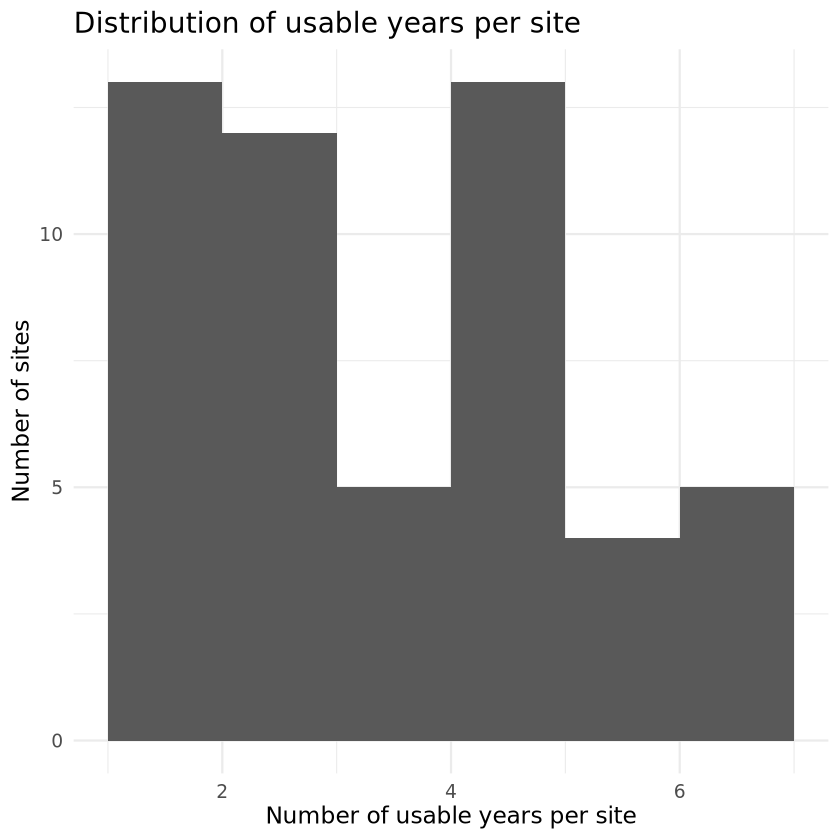

In [5]:
years_per_site <- as.data.frame(dt[, .N, by = SITE_ID])
setnames(years_per_site, "N", "n_years")

ggplot(years_per_site, aes(x = n_years)) +
  geom_histogram(binwidth = 1, boundary = 0, closed = "left") +
  labs(
    title = "Distribution of usable years per site",
    x = "Number of usable years per site",
    y = "Number of sites"
  ) +
  theme_minimal(base_size = 14)

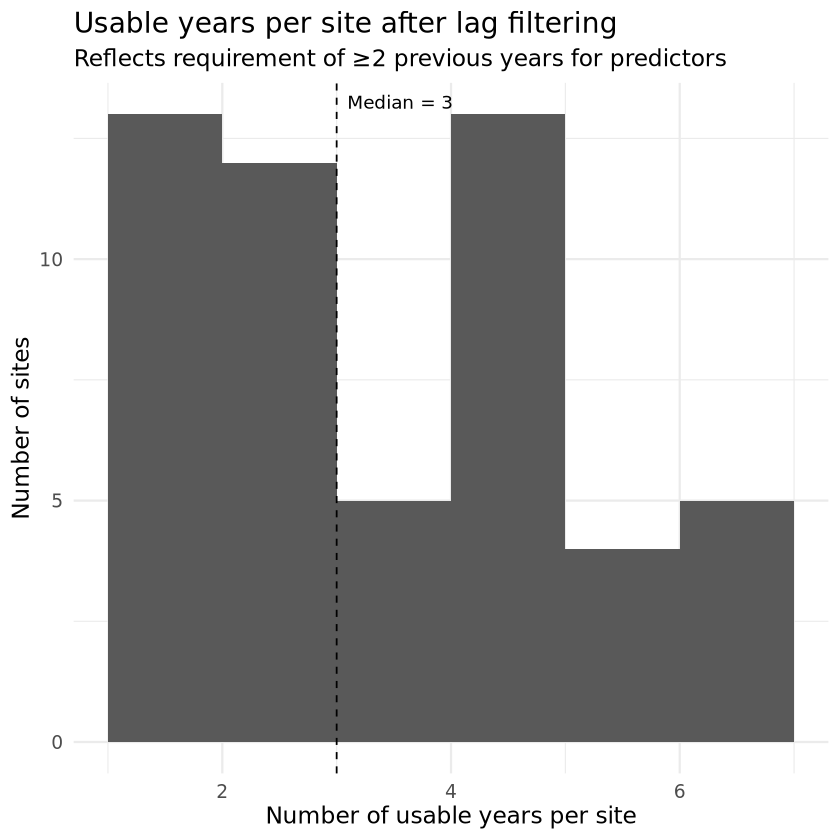

In [7]:
median_years <- median(years_per_site$n_years)

ggplot(years_per_site, aes(x = n_years)) +
  geom_histogram(binwidth = 1, boundary = 0, closed = "left") +
  geom_vline(xintercept = median_years, linetype = "dashed") +
  annotate("text",
           x = median_years,
           y = Inf,
           label = paste("Median =", median_years),
           vjust = 2,
           hjust = -0.1) +
  labs(
    title = "Usable years per site after lag filtering",
    subtitle = "Reflects requirement of ≥2 previous years for predictors",
    x = "Number of usable years per site",
    y = "Number of sites"
  ) +
  theme_minimal(base_size = 14)

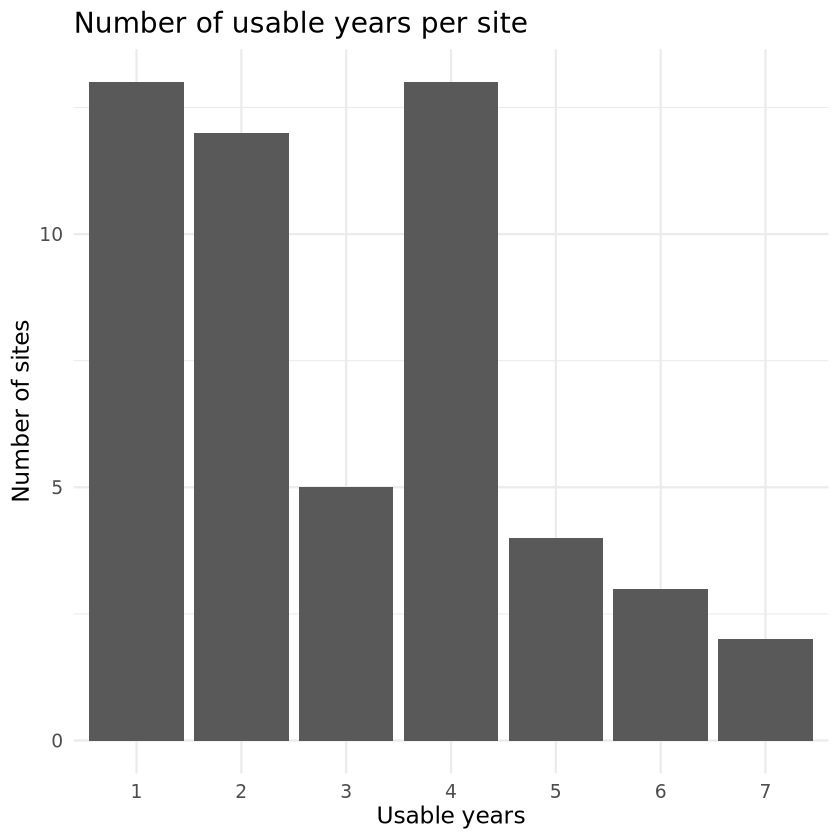

In [8]:
ggplot(years_per_site, aes(x = factor(n_years))) +
  geom_bar() +
  labs(
    title = "Number of usable years per site",
    x = "Usable years",
    y = "Number of sites"
  ) +
  theme_minimal(base_size = 14)

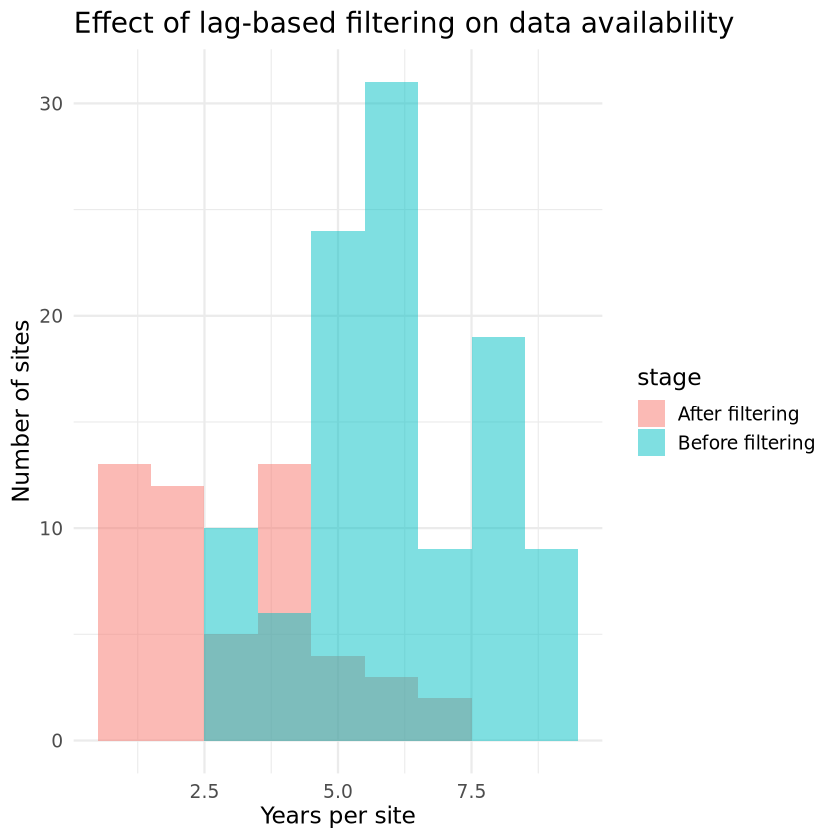

In [9]:
dt_before <- fread("derived_tables/modeldata_3yr_with_meteolags_clean.csv")

before_counts <- dt_before[, .N, by = SITE_ID]
after_counts  <- dt[, .N, by = SITE_ID]

before_counts[, stage := "Before filtering"]
after_counts[, stage := "After filtering"]

plot_dt <- rbindlist(list(before_counts, after_counts), fill = TRUE)
setnames(plot_dt, "N", "n_years")

ggplot(plot_dt, aes(x = n_years, fill = stage)) +
  geom_histogram(binwidth = 1, position = "identity", alpha = 0.5) +
  labs(
    title = "Effect of lag-based filtering on data availability",
    x = "Years per site",
    y = "Number of sites"
  ) +
  theme_minimal(base_size = 14)

In [ ]:
library(data.table)
library(ranger)

# =========================================================
# STEP 11 UPDATED: Batch LOSO RF for ALL EFPs
#                   3-year dataset + lag24 + anomaly memory
# =========================================================

# ---------------------------------------------------------
# 1) Load MASTER dataset
# ---------------------------------------------------------
## before adding the deadwood lag
dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")
## adding the deadwood lag 1 and 2
#dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv")
cat("Loaded MASTER 3-year dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

# keep only existing
trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]

cat("Trait vars    :", length(trait_vars), "\n")
cat("Deadwood vars :", length(deadwood_vars), "\n")
cat("Lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars   :", length(anom_lag_vars), "\n")

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo24 = lag24_vars,
  meteo24_traits = c(lag24_vars, trait_vars),
  meteo24_deadwood = c(lag24_vars, deadwood_vars),
  meteo24_traits_deadwood = c(lag24_vars, trait_vars, deadwood_vars),
  meteo24_deadwood_memory = c(lag24_vars, deadwood_vars, anom_lag_vars),
  meteo24_traits_deadwood_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

# quick check
cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    if (length(xvars) == 0) {
      stop("No predictor variables left for model: ", model_name)
    }
    
    rf_fit <- ranger(
      x = train_dt[, ..xvars],
      y = train_dt[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_dt[, ..xvars])$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo24_3yr"),
      paste0("M02_", resp, "_meteo24_traits_3yr"),
      paste0("M03_", resp, "_meteo24_deadwood_3yr"),
      paste0("M04_", resp, "_meteo24_traits_deadwood_3yr"),
      paste0("M05_", resp, "_meteo24_deadwood_memory_3yr"),
      paste0("M06_", resp, "_meteo24_traits_deadwood_memory_3yr")
    ),
    predictor_set = c(
      "meteo24",
      "meteo24_traits",
      "meteo24_deadwood",
      "meteo24_traits_deadwood",
      "meteo24_deadwood_memory",
      "meteo24_traits_deadwood_memory"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, "derived_tables/EFP_batch_metrics_ALL_3yr_lag24_memory.csv")
fwrite(all_predictions, "derived_tables/EFP_batch_predictions_ALL_3yr_lag24_memory.csv")
fwrite(all_varimp, "derived_tables/EFP_batch_varimp_ALL_3yr_lag24_memory.csv")

cat("\n=============================\n")
cat("ALL 3-YEAR LAG24 MODELS COMPLETED\n")
cat("=============================\n")

cat("\nMetrics preview:\n")
print(all_metrics)

cat("\nFiles written:\n")
cat("- derived_tables/EFP_batch_metrics_ALL_3yr_lag24_memory.csv\n")
cat("- derived_tables/EFP_batch_predictions_ALL_3yr_lag24_memory.csv\n")
cat("- derived_tables/EFP_batch_varimp_ALL_3yr_lag24_memory.csv\n")

Loaded MASTER 3-year dataset: 120 rows x 349 cols
Trait vars    : 21 
Deadwood vars : 8 
Lag24 vars    : 288 
Memory vars   : 8 

Predictor set sizes:
meteo24 : 288 
meteo24_traits : 309 
meteo24_deadwood : 296 
meteo24_traits_deadwood : 317 
meteo24_deadwood_memory : 304 
meteo24_traits_deadwood_memory : 325 


In [ ]:
library(data.table)
library(ranger)

# =========================================================
# STEP 11 FINAL: Batch LOSO RF for ALL EFPs
# 3-year dataset + lag24 + memory + extra comparison model
# =========================================================

# ---------------------------------------------------------
# 0) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load MASTER dataset
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded MASTER 3-year dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

# keep only existing
trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]

cat("Trait vars    :", length(trait_vars), "\n")
cat("Deadwood vars :", length(deadwood_vars), "\n")
cat("Lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars   :", length(anom_lag_vars), "\n")

# save variable lists for reproducibility
writeLines(trait_vars,    file.path(out_dir, "vars_traits_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_used.txt"))
writeLines(lag24_vars,    file.path(out_dir, "vars_meteo_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_used.txt"))

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo24 = lag24_vars,
  meteo24_traits = c(lag24_vars, trait_vars),
  meteo24_deadwood = c(lag24_vars, deadwood_vars),
  meteo24_traits_deadwood = c(lag24_vars, trait_vars, deadwood_vars),
  meteo24_deadwood_memory = c(lag24_vars, deadwood_vars, anom_lag_vars),
  meteo24_traits_deadwood_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars),
  meteo24_traits_memory = c(lag24_vars, trait_vars, anom_lag_vars)   # NEW MODEL
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    if (length(xvars) == 0) {
      stop("No predictor variables left for model: ", model_name)
    }
    
    rf_fit <- ranger(
      x = train_dt[, ..xvars],
      y = train_dt[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_dt[, ..xvars])$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo24_3yr"),
      paste0("M02_", resp, "_meteo24_traits_3yr"),
      paste0("M03_", resp, "_meteo24_deadwood_3yr"),
      paste0("M04_", resp, "_meteo24_traits_deadwood_3yr"),
      paste0("M05_", resp, "_meteo24_deadwood_memory_3yr"),
      paste0("M06_", resp, "_meteo24_traits_deadwood_memory_3yr"),
      paste0("M07_", resp, "_meteo24_traits_memory_3yr")   # NEW
    ),
    predictor_set = c(
      "meteo24",
      "meteo24_traits",
      "meteo24_deadwood",
      "meteo24_traits_deadwood",
      "meteo24_deadwood_memory",
      "meteo24_traits_deadwood_memory",
      "meteo24_traits_memory"   # NEW
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics,     file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_memory_final.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_memory_final.csv"))
fwrite(all_varimp,      file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_memory_final.csv"))

# save the exact master dataset used
fwrite(dt, file.path(out_dir, "modeldata_MASTER_complete_3yr_lag24_anomlag12_used.csv"))

cat("\n=============================\n")
cat("ALL 3-YEAR LAG24 MODELS COMPLETED\n")
cat("=============================\n")

cat("\nMetrics preview:\n")
print(all_metrics)

cat("\nFiles written:\n")
cat("-", file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_memory_final.csv"), "\n")
cat("-", file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_memory_final.csv"), "\n")
cat("-", file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_memory_final.csv"), "\n")
cat("-", file.path(out_dir, "modeldata_MASTER_complete_3yr_lag24_anomlag12_used.csv"), "\n")
cat("-", file.path(out_dir, "vars_traits_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_deadwood_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_meteo_lag24_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_memory_used.txt"), "\n")

Loaded MASTER 3-year dataset: 156 rows x 335 cols
Trait vars    : 21 
Deadwood vars : 7 
Lag24 vars    : 288 
Memory vars   : 8 

Predictor set sizes:
meteo24 : 288 
meteo24_traits : 309 
meteo24_deadwood : 295 
meteo24_traits_deadwood : 316 
meteo24_deadwood_memory : 303 
meteo24_traits_deadwood_memory : 324 
meteo24_traits_memory : 317 

Processing response: uWUE 
Running M01_uWUE_meteo24_3yr - fold 1 of 52 - test site: AU-Boy 
Running M01_uWUE_meteo24_3yr - fold 2 of 52 - test site: AU-GWW 
Running M01_uWUE_meteo24_3yr - fold 3 of 52 - test site: AU-War 
Running M01_uWUE_meteo24_3yr - fold 4 of 52 - test site: AU-Whr 
Running M01_uWUE_meteo24_3yr - fold 5 of 52 - test site: AU-Wom 
Running M01_uWUE_meteo24_3yr - fold 6 of 52 - test site: CA-Cbo 
Running M01_uWUE_meteo24_3yr - fold 7 of 52 - test site: CA-EM1 
Running M01_uWUE_meteo24_3yr - fold 8 of 52 - test site: CA-TPD 
Running M01_uWUE_meteo24_3yr - fold 9 of 52 - test site: CL-SDF 
Running M01_uWUE_meteo24_3yr - fold 10 of 52 -

In [5]:
library(data.table)
library(ranger)

# =========================================================
# STEP 11 UPDATED: Batch LOSO RF for ALL EFPs
# 3-year dataset + lag24 + anomaly memory + deadwood lag1/lag2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_deadwoodLag12_500m"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load MASTER dataset with deadwood lag1/lag2
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv")

cat("Loaded MASTER 3-year dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")
deadwood_current_vars <- readLines("derived_tables/vars_deadwood_current_master_3yr.txt")
deadwood_lag_vars <- readLines("derived_tables/vars_deadwood_lag12_master_3yr.txt")
forest_context_vars <- readLines("derived_tables/vars_forest_context_master_3yr.txt")

trait_vars <- trait_vars[trait_vars %in% names(dt)]
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]
deadwood_current_vars <- deadwood_current_vars[deadwood_current_vars %in% names(dt)]
deadwood_lag_vars <- deadwood_lag_vars[deadwood_lag_vars %in% names(dt)]
forest_context_vars <- forest_context_vars[forest_context_vars %in% names(dt)]

deadwood_vars <- c(deadwood_current_vars, deadwood_lag_vars)

cat("Trait vars          :", length(trait_vars), "\n")
cat("Meteo lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars         :", length(anom_lag_vars), "\n")
cat("Deadwood current    :", length(deadwood_current_vars), "\n")
cat("Deadwood lag1/lag2  :", length(deadwood_lag_vars), "\n")
cat("Deadwood total      :", length(deadwood_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_used.txt"))
writeLines(deadwood_current_vars, file.path(out_dir, "vars_deadwood_current_used.txt"))
writeLines(deadwood_lag_vars, file.path(out_dir, "vars_deadwood_lag12_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_current_lag12_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo = lag24_vars,
  meteo_disturbance = c(lag24_vars, deadwood_vars),
  meteo_traits = c(lag24_vars, trait_vars),
  meteo_traits_disturbance = c(lag24_vars, trait_vars, deadwood_vars),
  meteo_memory = c(lag24_vars, anom_lag_vars),
  meteo_memory_disturbance = c(lag24_vars, anom_lag_vars, deadwood_vars),
  meteo_traits_memory = c(lag24_vars, trait_vars, anom_lag_vars),
  meteo_traits_disturbance_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars),
  meteo_traits_disturbance_memory_context = c(
    lag24_vars, trait_vars, deadwood_vars, anom_lag_vars, forest_context_vars
  )
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- unique(c("SITE_ID", "year", response_var, predictor_vars))
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  model_dt <- model_dt[!is.na(get(response_var))]
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[
      complete.cases(train_dt[, c(response_var, xvars), with = FALSE])
    ]
    
    test_complete <- test_dt[
      complete.cases(test_dt[, xvars, with = FALSE])
    ]
    
    if (length(xvars) == 0 || nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[year %in% test_complete$year, predicted := as.numeric(pred)]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  if (nrow(varimp_dt) > 0) {
    varimp_mean <- varimp_dt[, .(
      mean_importance = mean(importance, na.rm = TRUE)
    ), by = .(model, response, variable)]
    setorder(varimp_mean, -mean_importance)
  } else {
    varimp_mean <- data.table(
      model = character(),
      response = character(),
      variable = character(),
      mean_importance = numeric()
    )
  }
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo"),
      paste0("M02_", resp, "_meteo_disturbance"),
      paste0("M03_", resp, "_meteo_traits"),
      paste0("M04_", resp, "_meteo_traits_disturbance"),
      paste0("M05_", resp, "_meteo_memory"),
      paste0("M06_", resp, "_meteo_memory_disturbance"),
      paste0("M07_", resp, "_meteo_traits_memory"),
      paste0("M08_", resp, "_meteo_traits_disturbance_memory"),
      paste0("M09_", resp, "_meteo_traits_disturbance_memory_context")
    ),
    predictor_set = c(
      "meteo",
      "meteo_disturbance",
      "meteo_traits",
      "meteo_traits_disturbance",
      "meteo_memory",
      "meteo_memory_disturbance",
      "meteo_traits_memory",
      "meteo_traits_disturbance_memory",
      "meteo_traits_disturbance_memory_context"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_anomlag12_deadwoodLag12.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_anomlag12_deadwoodLag12.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_anomlag12_deadwoodLag12.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded MASTER 3-year dataset: 120 rows x 349 cols
Sites: 45 
Trait vars          : 21 
Meteo lag24 vars    : 288 
Memory vars         : 8 
Deadwood current    : 7 
Deadwood lag1/lag2  : 14 
Deadwood total      : 21 
Forest context vars : 1 

Predictor set sizes:
meteo : 288 
meteo_disturbance : 309 
meteo_traits : 309 
meteo_traits_disturbance : 330 
meteo_memory : 296 
meteo_memory_disturbance : 317 
meteo_traits_memory : 317 
meteo_traits_disturbance_memory : 338 
meteo_traits_disturbance_memory_context : 339 

Processing response: uWUE 
Running M01_uWUE_meteo - fold 1 of 45 - test site: AU-Boy 
Running M01_uWUE_meteo - fold 2 of 45 - test site: AU-GWW 
Running M01_uWUE_meteo - fold 3 of 45 - test site: AU-War 
Running M01_uWUE_meteo - fold 4 of 45 - test site: AU-Whr 
Running M01_uWUE_meteo - fold 5 of 45 - test site: AU-Wom 
Running M01_uWUE_meteo - fold 6 of 45 - test site: CA-Cbo 
Running M01_uWUE_meteo - fold 7 of 45 - test site: CA-EM1 
Running M01_uWUE_meteo - fold 8 of 45 - t

In [7]:
#### forest cover part of disturb var
library(data.table)
library(ranger)

# =========================================================
# STEP 11 UPDATED: Batch LOSO RF for ALL EFPs
# 3-year dataset + lag24 + anomaly memory + deadwood lag1/lag2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_deadwoodLag12_500m"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load MASTER dataset with deadwood lag1/lag2
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_deadwoodLag12.csv")

cat("Loaded MASTER 3-year dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")
deadwood_current_vars <- readLines("derived_tables/vars_deadwood_current_master_3yr.txt")
deadwood_lag_vars <- readLines("derived_tables/vars_deadwood_lag12_master_3yr.txt")
forest_context_vars <- readLines("derived_tables/vars_forest_context_master_3yr.txt")

trait_vars <- trait_vars[trait_vars %in% names(dt)]
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]
deadwood_current_vars <- deadwood_current_vars[deadwood_current_vars %in% names(dt)]
deadwood_lag_vars <- deadwood_lag_vars[deadwood_lag_vars %in% names(dt)]
forest_context_vars <- forest_context_vars[forest_context_vars %in% names(dt)]

deadwood_vars <- c(deadwood_current_vars, deadwood_lag_vars, forest_context_vars)

cat("Trait vars          :", length(trait_vars), "\n")
cat("Meteo lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars         :", length(anom_lag_vars), "\n")
cat("Deadwood current    :", length(deadwood_current_vars), "\n")
cat("Deadwood lag1/lag2  :", length(deadwood_lag_vars), "\n")
cat("Deadwood total      :", length(deadwood_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_used.txt"))
writeLines(deadwood_current_vars, file.path(out_dir, "vars_deadwood_current_used.txt"))
writeLines(deadwood_lag_vars, file.path(out_dir, "vars_deadwood_lag12_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_current_lag12_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo = lag24_vars,
  meteo_disturbance = c(lag24_vars, deadwood_vars),
  meteo_traits = c(lag24_vars, trait_vars),
  meteo_traits_disturbance = c(lag24_vars, trait_vars, deadwood_vars),
  meteo_memory = c(lag24_vars, anom_lag_vars),
  meteo_memory_disturbance = c(lag24_vars, anom_lag_vars, deadwood_vars),
  meteo_traits_memory = c(lag24_vars, trait_vars, anom_lag_vars),
  meteo_traits_disturbance_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- unique(c("SITE_ID", "year", response_var, predictor_vars))
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  model_dt <- model_dt[!is.na(get(response_var))]
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[
      complete.cases(train_dt[, c(response_var, xvars), with = FALSE])
    ]
    
    test_complete <- test_dt[
      complete.cases(test_dt[, xvars, with = FALSE])
    ]
    
    if (length(xvars) == 0 || nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[year %in% test_complete$year, predicted := as.numeric(pred)]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  if (nrow(varimp_dt) > 0) {
    varimp_mean <- varimp_dt[, .(
      mean_importance = mean(importance, na.rm = TRUE)
    ), by = .(model, response, variable)]
    setorder(varimp_mean, -mean_importance)
  } else {
    varimp_mean <- data.table(
      model = character(),
      response = character(),
      variable = character(),
      mean_importance = numeric()
    )
  }
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
  model_name = c(
    paste0("M01_", resp, "_meteo"),
    paste0("M02_", resp, "_meteo_disturbance"),
    paste0("M03_", resp, "_meteo_traits"),
    paste0("M04_", resp, "_meteo_traits_disturbance"),
    paste0("M05_", resp, "_meteo_memory"),
    paste0("M06_", resp, "_meteo_memory_disturbance"),
    paste0("M07_", resp, "_meteo_traits_memory"),
    paste0("M08_", resp, "_meteo_traits_disturbance_memory")
  ),
  predictor_set = c(
    "meteo",
    "meteo_disturbance",
    "meteo_traits",
    "meteo_traits_disturbance",
    "meteo_memory",
    "meteo_memory_disturbance",
    "meteo_traits_memory",
    "meteo_traits_disturbance_memory"
  )
)
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_anomlag12_deadwoodLag12Forest.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_anomlag12_deadwoodLag12Forest.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_anomlag12_deadwoodLag12Forest.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded MASTER 3-year dataset: 120 rows x 349 cols
Sites: 45 
Trait vars          : 21 
Meteo lag24 vars    : 288 
Memory vars         : 8 
Deadwood current    : 7 
Deadwood lag1/lag2  : 14 
Deadwood total      : 22 
Forest context vars : 1 

Predictor set sizes:
meteo : 288 
meteo_disturbance : 310 
meteo_traits : 309 
meteo_traits_disturbance : 331 
meteo_memory : 296 
meteo_memory_disturbance : 318 
meteo_traits_memory : 317 
meteo_traits_disturbance_memory : 339 

Processing response: uWUE 
Running M01_uWUE_meteo - fold 1 of 45 - test site: AU-Boy 
Running M01_uWUE_meteo - fold 2 of 45 - test site: AU-GWW 
Running M01_uWUE_meteo - fold 3 of 45 - test site: AU-War 
Running M01_uWUE_meteo - fold 4 of 45 - test site: AU-Whr 
Running M01_uWUE_meteo - fold 5 of 45 - test site: AU-Wom 
Running M01_uWUE_meteo - fold 6 of 45 - test site: CA-Cbo 
Running M01_uWUE_meteo - fold 7 of 45 - test site: CA-EM1 
Running M01_uWUE_meteo - fold 8 of 45 - test site: CA-TPD 
Running M01_uWUE_meteo - fold

In [11]:
#### Multibuffer with disturbance lag
#### forest cover part of disturb var
library(data.table)
library(ranger)

# =========================================================
# STEP 11 UPDATED: Batch LOSO RF for ALL EFPs
# 3-year dataset + lag24 + anomaly memory + deadwood lag1/lag2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_multibuffer_deadwoodLag12"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load MASTER dataset with deadwood lag1/lag2
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_deadwoodLag12.csv")

cat("Loaded MASTER 3-year dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")
deadwood_current_vars <- readLines(
  "derived_tables/vars_deadwood_multibuffer_current_master_3yr.txt"
)
deadwood_lag_vars <- readLines(
  "derived_tables/vars_deadwood_multibuffer_lag12_master_3yr.txt"
)
forest_context_vars <- readLines(
  "derived_tables/vars_forest_context_multibuffer_master_3yr.txt"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]
deadwood_current_vars <- deadwood_current_vars[deadwood_current_vars %in% names(dt)]
deadwood_lag_vars <- deadwood_lag_vars[deadwood_lag_vars %in% names(dt)]
forest_context_vars <- forest_context_vars[forest_context_vars %in% names(dt)]

deadwood_vars <- c(deadwood_current_vars, deadwood_lag_vars, forest_context_vars)

cat("Trait vars          :", length(trait_vars), "\n")
cat("Meteo lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars         :", length(anom_lag_vars), "\n")
cat("Deadwood current    :", length(deadwood_current_vars), "\n")
cat("Deadwood lag1/lag2  :", length(deadwood_lag_vars), "\n")
cat("Deadwood total      :", length(deadwood_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_used.txt"))
writeLines(deadwood_current_vars, file.path(out_dir, "vars_deadwood_current_used.txt"))
writeLines(deadwood_lag_vars, file.path(out_dir, "vars_deadwood_lag12_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_current_lag12_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo = lag24_vars,
  meteo_disturbance = c(lag24_vars, deadwood_vars),
  meteo_traits = c(lag24_vars, trait_vars),
  meteo_traits_disturbance = c(lag24_vars, trait_vars, deadwood_vars),
  meteo_memory = c(lag24_vars, anom_lag_vars),
  meteo_memory_disturbance = c(lag24_vars, anom_lag_vars, deadwood_vars),
  meteo_traits_memory = c(lag24_vars, trait_vars, anom_lag_vars),
  meteo_traits_disturbance_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- unique(c("SITE_ID", "year", response_var, predictor_vars))
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  model_dt <- model_dt[!is.na(get(response_var))]
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[
      complete.cases(train_dt[, c(response_var, xvars), with = FALSE])
    ]
    
    test_complete <- test_dt[
      complete.cases(test_dt[, xvars, with = FALSE])
    ]
    
    if (length(xvars) == 0 || nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[year %in% test_complete$year, predicted := as.numeric(pred)]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  if (nrow(varimp_dt) > 0) {
    varimp_mean <- varimp_dt[, .(
      mean_importance = mean(importance, na.rm = TRUE)
    ), by = .(model, response, variable)]
    setorder(varimp_mean, -mean_importance)
  } else {
    varimp_mean <- data.table(
      model = character(),
      response = character(),
      variable = character(),
      mean_importance = numeric()
    )
  }
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
  model_name = c(
    paste0("M01_", resp, "_meteo"),
    paste0("M02_", resp, "_meteo_disturbance"),
    paste0("M03_", resp, "_meteo_traits"),
    paste0("M04_", resp, "_meteo_traits_disturbance"),
    paste0("M05_", resp, "_meteo_memory"),
    paste0("M06_", resp, "_meteo_memory_disturbance"),
    paste0("M07_", resp, "_meteo_traits_memory"),
    paste0("M08_", resp, "_meteo_traits_disturbance_memory")
  ),
  predictor_set = c(
    "meteo",
    "meteo_disturbance",
    "meteo_traits",
    "meteo_traits_disturbance",
    "meteo_memory",
    "meteo_memory_disturbance",
    "meteo_traits_memory",
    "meteo_traits_disturbance_memory"
  )
)
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_anomlag12_multibuffer_deadwoodLag12Forest.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_anomlag12_multibuffer_deadwoodLag12Forest.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_anomlag12_multibuffer_deadwoodLag12Forest.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded MASTER 3-year dataset: 70 rows x 438 cols
Sites: 30 
Trait vars          : 21 
Meteo lag24 vars    : 288 
Memory vars         : 8 
Deadwood current    : 35 
Deadwood lag1/lag2  : 70 
Deadwood total      : 110 
Forest context vars : 5 

Predictor set sizes:
meteo : 288 
meteo_disturbance : 398 
meteo_traits : 309 
meteo_traits_disturbance : 419 
meteo_memory : 296 
meteo_memory_disturbance : 406 
meteo_traits_memory : 317 
meteo_traits_disturbance_memory : 427 

Processing response: uWUE 
Running M01_uWUE_meteo - fold 1 of 30 - test site: AU-Boy 
Running M01_uWUE_meteo - fold 2 of 30 - test site: AU-GWW 
Running M01_uWUE_meteo - fold 3 of 30 - test site: AU-War 
Running M01_uWUE_meteo - fold 4 of 30 - test site: AU-Wom 
Running M01_uWUE_meteo - fold 5 of 30 - test site: CA-Cbo 
Running M01_uWUE_meteo - fold 6 of 30 - test site: CA-TPD 
Running M01_uWUE_meteo - fold 7 of 30 - test site: CZ-RAJ 
Running M01_uWUE_meteo - fold 8 of 30 - test site: CZ-Stn 
Running M01_uWUE_meteo - fol

In [1]:
## with different buffer:
library(data.table)
library(ranger)

# =========================================================
# STEP 11 FINAL: Batch LOSO RF for ALL EFPs
# 3-year dataset + lag24 + memory + multibuffer deadwood
# =========================================================

# ---------------------------------------------------------
# 0) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr_multibuffer"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load MASTER dataset WITH MULTIBUFFER DISTURBANCE
# ---------------------------------------------------------

dt <- fread("derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv")

cat("Loaded MASTER 3-year multibuffer dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# ---------------------------------------------------------
# 2) Define variable groups
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
anom_lag_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

# ---------------------------------------------------------
# 2b) Auto-detect multibuffer deadwood/forest variables
# ---------------------------------------------------------

deadwood_patterns <- c(
  "^forest_mean_pct_[0-9]+m$",
  "^loss_area_frac_[0-9]+m$",
  "^loss_mean_pp_[0-9]+m$",
  "^loss_sum_pp_[0-9]+m$",
  "^deadwood_mean_pct_[0-9]+m$",
  "^deadwood_increase_area_frac_[0-9]+m$",
  "^deadwood_increase_mean_pp_[0-9]+m$",
  "^deadwood_increase_sum_pp_[0-9]+m$"
)

deadwood_vars <- unique(unlist(lapply(deadwood_patterns, function(p) {
  grep(p, names(dt), value = TRUE)
})))

# keep only existing
trait_vars    <- trait_vars[trait_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
anom_lag_vars <- anom_lag_vars[anom_lag_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]

cat("Trait vars    :", length(trait_vars), "\n")
cat("Deadwood vars :", length(deadwood_vars), "\n")
cat("Lag24 vars    :", length(lag24_vars), "\n")
cat("Memory vars   :", length(anom_lag_vars), "\n")

# save variable lists for reproducibility
writeLines(trait_vars,    file.path(out_dir, "vars_traits_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_multibuffer_used.txt"))
writeLines(lag24_vars,    file.path(out_dir, "vars_meteo_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_used.txt"))

# ---------------------------------------------------------
# 3) Define predictor sets
# ---------------------------------------------------------

pred_sets <- list(
  meteo24 = lag24_vars,
  meteo24_traits = c(lag24_vars, trait_vars),
  meteo24_deadwood = c(lag24_vars, deadwood_vars),
  meteo24_traits_deadwood = c(lag24_vars, trait_vars, deadwood_vars),
  meteo24_deadwood_memory = c(lag24_vars, deadwood_vars, anom_lag_vars),
  meteo24_traits_deadwood_memory = c(lag24_vars, trait_vars, deadwood_vars, anom_lag_vars),
  meteo24_traits_memory = c(lag24_vars, trait_vars, anom_lag_vars)
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# ---------------------------------------------------------
# 4) LOSO function
# ---------------------------------------------------------

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  
  if (!(response_var %in% names(model_dt))) {
    stop("Response variable not found: ", response_var)
  }
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  if (length(site_ids) < 2) {
    stop("Need at least 2 sites for LOSO.")
  }
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    if (length(xvars) == 0) {
      stop("No predictor variables left for model: ", model_name)
    }
    
    rf_fit <- ranger(
      x = train_dt[, ..xvars],
      y = train_dt[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_dt[, ..xvars])$predictions
    
    pred_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = as.numeric(pred)
    )
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    r2 <- cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    r2 <- NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# ---------------------------------------------------------
# 5) Loop over all EFP responses
# ---------------------------------------------------------

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo24_3yr"),
      paste0("M02_", resp, "_meteo24_traits_3yr"),
      paste0("M03_", resp, "_meteo24_deadwoodMB_3yr"),
      paste0("M04_", resp, "_meteo24_traits_deadwoodMB_3yr"),
      paste0("M05_", resp, "_meteo24_deadwoodMB_memory_3yr"),
      paste0("M06_", resp, "_meteo24_traits_deadwoodMB_memory_3yr"),
      paste0("M07_", resp, "_meteo24_traits_memory_3yr")
    ),
    predictor_set = c(
      "meteo24",
      "meteo24_traits",
      "meteo24_deadwood",
      "meteo24_traits_deadwood",
      "meteo24_deadwood_memory",
      "meteo24_traits_deadwood_memory",
      "meteo24_traits_memory"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# ---------------------------------------------------------
# 6) Combine everything
# ---------------------------------------------------------

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

fwrite(all_metrics,     file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_memory_multibuffer.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_memory_multibuffer.csv"))
fwrite(all_varimp,      file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_memory_multibuffer.csv"))

# save the exact master dataset used
fwrite(dt, file.path(out_dir, "modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_used.csv"))

cat("\n=============================\n")
cat("ALL 3-YEAR LAG24 MULTIBUFFER MODELS COMPLETED\n")
cat("=============================\n")

cat("\nMetrics preview:\n")
print(all_metrics)

cat("\nFiles written:\n")
cat("-", file.path(out_dir, "EFP_batch_metrics_ALL_3yr_lag24_memory_multibuffer.csv"), "\n")
cat("-", file.path(out_dir, "EFP_batch_predictions_ALL_3yr_lag24_memory_multibuffer.csv"), "\n")
cat("-", file.path(out_dir, "EFP_batch_varimp_ALL_3yr_lag24_memory_multibuffer.csv"), "\n")
cat("-", file.path(out_dir, "modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_used.csv"), "\n")
cat("-", file.path(out_dir, "vars_traits_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_deadwood_multibuffer_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_meteo_lag24_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_memory_used.txt"), "\n")

Loaded MASTER 3-year multibuffer dataset: 156 rows x 367 cols
Trait vars    : 21 
Deadwood vars : 40 
Lag24 vars    : 288 
Memory vars   : 8 

Predictor set sizes:
meteo24 : 288 
meteo24_traits : 309 
meteo24_deadwood : 328 
meteo24_traits_deadwood : 349 
meteo24_deadwood_memory : 336 
meteo24_traits_deadwood_memory : 357 
meteo24_traits_memory : 317 

Processing response: uWUE 
Running M01_uWUE_meteo24_3yr - fold 1 of 52 - test site: AU-Boy 
Running M01_uWUE_meteo24_3yr - fold 2 of 52 - test site: AU-GWW 
Running M01_uWUE_meteo24_3yr - fold 3 of 52 - test site: AU-War 
Running M01_uWUE_meteo24_3yr - fold 4 of 52 - test site: AU-Whr 
Running M01_uWUE_meteo24_3yr - fold 5 of 52 - test site: AU-Wom 
Running M01_uWUE_meteo24_3yr - fold 6 of 52 - test site: CA-Cbo 
Running M01_uWUE_meteo24_3yr - fold 7 of 52 - test site: CA-EM1 
Running M01_uWUE_meteo24_3yr - fold 8 of 52 - test site: CA-TPD 
Running M01_uWUE_meteo24_3yr - fold 9 of 52 - test site: CL-SDF 
Running M01_uWUE_meteo24_3yr - fo

In [16]:
# ---------------------------------------------------------
# DEADWOOD / FOREST VARIABLES GROUPED BY RADIUS
# ---------------------------------------------------------

buffer_radii <- c(100, 200, 300, 400, 500)

deadwood_by_radius <- list()

for (r in buffer_radii) {
  
  rlab <- paste0(r, "m")
  
  deadwood_by_radius[[rlab]] <- c(
    paste0("forest_mean_pct_", rlab),
    paste0("loss_area_frac_", rlab),
    paste0("loss_mean_pp_", rlab),
    paste0("loss_sum_pp_", rlab),
    paste0("deadwood_mean_pct_", rlab),
    paste0("deadwood_increase_area_frac_", rlab),
    paste0("deadwood_increase_mean_pp_", rlab),
    paste0("deadwood_increase_sum_pp_", rlab)
  )
  
  # keep only columns that really exist
  deadwood_by_radius[[rlab]] <- deadwood_by_radius[[rlab]][
    deadwood_by_radius[[rlab]] %in% names(dt)
  ]
}

# quick check
cat("\nDeadwood variables by radius:\n")
for (nm in names(deadwood_by_radius)) {
  cat(nm, ":", length(deadwood_by_radius[[nm]]), "\n")
  print(deadwood_by_radius[[nm]])
  cat("\n")
}


Deadwood variables by radius:
100m : 8 
[1] "forest_mean_pct_100m"             "loss_area_frac_100m"             
[3] "loss_mean_pp_100m"                "loss_sum_pp_100m"                
[5] "deadwood_mean_pct_100m"           "deadwood_increase_area_frac_100m"
[7] "deadwood_increase_mean_pp_100m"   "deadwood_increase_sum_pp_100m"   

200m : 8 
[1] "forest_mean_pct_200m"             "loss_area_frac_200m"             
[3] "loss_mean_pp_200m"                "loss_sum_pp_200m"                
[5] "deadwood_mean_pct_200m"           "deadwood_increase_area_frac_200m"
[7] "deadwood_increase_mean_pp_200m"   "deadwood_increase_sum_pp_200m"   

300m : 8 
[1] "forest_mean_pct_300m"             "loss_area_frac_300m"             
[3] "loss_mean_pp_300m"                "loss_sum_pp_300m"                
[5] "deadwood_mean_pct_300m"           "deadwood_increase_area_frac_300m"
[7] "deadwood_increase_mean_pp_300m"   "deadwood_increase_sum_pp_300m"   

400m : 8 
[1] "forest_mean_pct_400m"            

In [2]:
### mark sites with high tree mortality
library(data.table)
library(ggplot2)

# =========================================================
# STEP 1: Define high-disturbance sites
# high disturbance = >= 2% in at least one available year
# =========================================================

out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dist <- fread("final_disturbance_52sites_multibuffer.csv")

if ("site_id" %in% names(dist)) {
  setnames(dist, "site_id", "SITE_ID")
}

# choose disturbance radius
# use 500m for consistency with your previous main disturbance plots
buffer_use <- "500m"

loss_var <- paste0("loss_mean_pp_", buffer_use)
deadwood_var <- paste0("deadwood_increase_mean_pp_", buffer_use)

dist[, disturbance_year := get(loss_var) + get(deadwood_var)]

dist_site_class <- dist[, .(
  max_disturbance_pct = max(disturbance_year, na.rm = TRUE),
  mean_disturbance_pct = mean(disturbance_year, na.rm = TRUE),
  n_years = .N
), by = SITE_ID]

dist_site_class[, disturbance_class := ifelse(
  max_disturbance_pct >= 2,
  "High disturbance",
  "Low disturbance"
)]

dist_site_class[, disturbance_class := factor(
  disturbance_class,
  levels = c("Low disturbance", "High disturbance")
)]

fwrite(
  dist_site_class,
  file.path(out_dir, "site_disturbance_class_ge2pct_any_year.csv")
)

print(dist_site_class[, .N, by = disturbance_class])

   disturbance_class     N
              <fctr> <int>
1:  High disturbance    25
2:   Low disturbance    27


In [6]:
library(data.table)

# =========================================================
# Add high-disturbance-site performance metrics
# columns: high_n_sites, high_RMSE, high_R2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load full metrics and predictions
# ---------------------------------------------------------

metrics <- fread(
  "derived_tables/final_results_3yr_multibuffer/EFP_batch_metrics_ALL_3yr_lag24_memory_multibuffer.csv"
)

pred <- fread(
  "derived_tables/final_results_3yr_multibuffer/EFP_batch_predictions_ALL_3yr_lag24_memory_multibuffer.csv"
)

# ---------------------------------------------------------
# 2) Load high-disturbance site classification
# ---------------------------------------------------------

dist_class <- fread(
  file.path(out_dir, "site_disturbance_class_ge2pct_any_year.csv")
)

high_sites <- dist_class[
  disturbance_class == "High disturbance",
  SITE_ID
]

cat("High-disturbance sites:", length(high_sites), "\n")

# ---------------------------------------------------------
# 3) Keep predictions only for high-disturbance sites
# ---------------------------------------------------------

pred_high <- pred[SITE_ID %in% high_sites]

# ---------------------------------------------------------
# 4) Calculate RMSE and R2 for high-disturbance sites
# ---------------------------------------------------------

high_metrics <- pred_high[, .(
  high_n_sites = uniqueN(SITE_ID),
  high_RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE)),
  high_R2 = ifelse(
    sum(!is.na(observed) & !is.na(predicted)) >= 2,
    cor(observed, predicted, use = "complete.obs")^2,
    NA_real_
  )
), by = .(model, response)]

# ---------------------------------------------------------
# 5) Merge with full table
# ---------------------------------------------------------

metrics_extended <- merge(
  metrics,
  high_metrics,
  by = c("model", "response"),
  all.x = TRUE
)

setorder(metrics_extended, response, model)

# ---------------------------------------------------------
# 6) Save
# ---------------------------------------------------------

fwrite(
  metrics_extended,
  file.path(out_dir, "EFP_model_performance_with_high_disturbance_metrics.csv")
)

print(metrics_extended)

cat("Saved:\n")
cat(file.path(out_dir, "EFP_model_performance_with_high_disturbance_metrics.csv"), "\n")

High-disturbance sites: 25 
                                              model response n_predictors
                                             <char>   <char>        <int>
 1:                           M01_ETmax_meteo24_3yr    ETmax          288
 2:                    M02_ETmax_meteo24_traits_3yr    ETmax          309
 3:                M03_ETmax_meteo24_deadwoodMB_3yr    ETmax          328
 4:         M04_ETmax_meteo24_traits_deadwoodMB_3yr    ETmax          349
 5:         M05_ETmax_meteo24_deadwoodMB_memory_3yr    ETmax          336
 6:  M06_ETmax_meteo24_traits_deadwoodMB_memory_3yr    ETmax          357
 7:             M07_ETmax_meteo24_traits_memory_3yr    ETmax          317
 8:                          M01_GPPsat_meteo24_3yr   GPPsat          288
 9:                   M02_GPPsat_meteo24_traits_3yr   GPPsat          309
10:               M03_GPPsat_meteo24_deadwoodMB_3yr   GPPsat          328
11:        M04_GPPsat_meteo24_traits_deadwoodMB_3yr   GPPsat          349
12:       

In [2]:
# =========================================================
# DARK STYLE VERSION
# Delta RMSE plot (same layout, dark theme)
# =========================================================

library(data.table)
library(ggplot2)
out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
plot_dt <- fread(
  file.path(out_dir, "deltaRMSE_M02_vs_M04_per_site_high_low_disturbance.csv")
)

# ---------------------------------------------------------
# colors (same as R2 dark plot)
# ---------------------------------------------------------

dist_cols <- c(
  "Low disturbance"  = "#18D5E8",
  "High disturbance" = "#FF3F8E"
)
plot_dt[, disturbance_class := factor(
  disturbance_class,
  levels = c("Low disturbance", "High disturbance")
)]
# ---------------------------------------------------------
# reorder from high delta RMSE to low
# ---------------------------------------------------------
plot_dt <- plot_dt[order(response, -delta_RMSE)]
plot_dt[, SITE_ID_facet := paste(response, SITE_ID, sep = "___")]
plot_dt[, SITE_ID_facet := factor(
  SITE_ID_facet,
  levels = unique(SITE_ID_facet)
)]

# ---------------------------------------------------------
# dark plot
# ---------------------------------------------------------

p_delta_dark <- ggplot(
  plot_dt,
  aes(
    x = delta_RMSE,
    y = SITE_ID_facet,
    fill = disturbance_class
  )
) +
  geom_col(
    color = "black",
    linewidth = 0.15
  ) +
  facet_wrap(
    ~response,
    scales = "free",
    ncol = 2
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed",
    linewidth = 0.7,
    color = "white"
  ) +
  scale_y_discrete(
    labels = function(x) sub(".*___", "", x)
  ) +
  scale_fill_manual(
    values = dist_cols,
    drop = FALSE
  ) +
  labs(
    title = "Effect of deadwood on model performance",
    subtitle = "High mortality = ≥2 percentage points in at least one year",
    x = expression(Delta * RMSE ~ "(M04 with deadwood -M02 base)"),
    y = "Site",
    fill = ""
  ) +
  theme_minimal(base_size = 17) +
  theme(
  plot.background = element_rect(fill = "black", color = NA),
  panel.background = element_rect(fill = "black", color = NA),
  strip.background = element_rect(
    fill = "grey20",
    color = "grey55"
  ),
  strip.text = element_text(
    size = 17,
    face = "bold",
    color = "white"
  ),
  panel.grid.major = element_line(
    color = "grey25",
    linewidth = 0.35
  ),
  panel.grid.minor = element_blank(),
  axis.line = element_line(color = "grey60"),
  axis.ticks = element_line(color = "grey60"),
  axis.text.y = element_text(
    size = 7,
    color = "white"
  ),
  axis.text.x = element_text(
    size = 13,
    color = "white"
  ),
  axis.title = element_text(
    size = 16,
    color = "white"
  ),
  plot.title = element_text(
    size = 23,
    face = "bold",
    color = "white"
  ),
  plot.subtitle = element_text(
    size = 16,
    color = "white"
  ),
  # -----------------------------
  # legend moved to TOP
  # -----------------------------
  legend.background = element_rect(
    fill = "black",
    color = "grey35"
  ),
  legend.key = element_rect(
    fill = "black",
    color = NA
  ),
  legend.text = element_text(
    size = 15,
    color = "white"
  ),
  legend.title = element_blank(),
  legend.position = "top",
  legend.direction = "horizontal",
  legend.justification = "center",
  legend.box = "horizontal"
)
# ---------------------------------------------------------
# save
# ---------------------------------------------------------

ggsave(
  file.path(out_dir, "plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.pdf"),
  p_delta_dark,
  width = 12,
  height = 12,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.png"),
  p_delta_dark,
  width = 12,
  height = 12,
  dpi = 300,
  bg = "black"
)

cat("Saved:\n")
cat("- plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.pdf\n")
cat("- plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.png\n")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High mortality = ≥2 percentage points in at least one year' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High mortality = ≥2 percentage points in at least one year' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High mortality = ≥2 percentage points in at least one year' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High mortality = ≥2 percentage points in at least one year' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High mortality = ≥2 percentage points in at least on

Saved:
- plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.pdf
- plot_deltaRMSE_M04_vs_M02_high_low_disturbance_dark.png


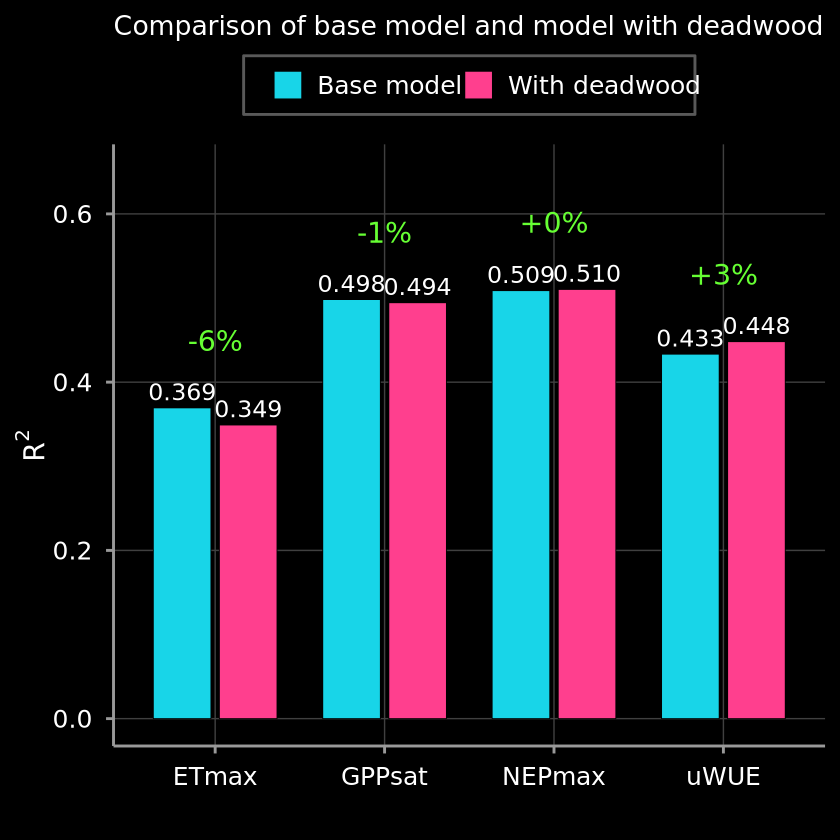

In [9]:
# =========================================================
# STEP 3: R2 bar plot for M02 vs M04 only
# Dark style + color code + percent improvement labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_multibuffer/EFP_batch_metrics_ALL_3yr_lag24_memory_multibuffer.csv"
)

efp_keep <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

metrics_m2m4 <- metrics[
  response %in% efp_keep &
    (grepl("^M02_", model) | grepl("^M04_", model))
]

metrics_m2m4[, model_group := fifelse(
  grepl("^M02_", model),
  "Base model",
  "With deadwood"
)]

metrics_m2m4[, model_group := factor(
  model_group,
  levels = c("Base model", "With deadwood")
)]

metrics_m2m4[, response := factor(
  response,
  levels = c("ETmax", "GPPsat", "NEPmax", "uWUE")
)]

bar_cols <- c(
  "Base model" = "#18D5E8",
  "With deadwood" = "#FF3F8E"
)

r2_wide <- dcast(
  metrics_m2m4,
  response ~ model_group,
  value.var = "R2"
)

r2_wide[, delta_R2 := `With deadwood` - `Base model`]

r2_wide[, pct_improvement := 100 * delta_R2 / `Base model`]

r2_wide[, label := paste0(
  ifelse(pct_improvement >= 0, "+", ""),
  sprintf("%.0f", pct_improvement),
  "%"
)]

label_dt <- merge(
  r2_wide[, .(response, delta_R2, pct_improvement, label)],
  metrics_m2m4[, .(ymax = max(R2, na.rm = TRUE)), by = response],
  by = "response"
)

label_dt[, y_pos := ymax + 0.08]

p_r2_dark <- ggplot(metrics_m2m4, aes(x = response, y = R2, fill = model_group)) +
  geom_col(
    position = position_dodge(width = 0.78),
    width = 0.68,
    color = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", R2)),
    position = position_dodge(width = 0.78),
    vjust = -0.45,
    size = 5,
    color = "white"
  ) +
  geom_text(
    data = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6,
    #fontface = "bold",
    color = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) + 0.06)
  ) +
  labs(
    #title = "Does deadwood improve model performance?",
    subtitle = "Comparison of base model and model with deadwood",
    x = "",
    y = expression(R^2),
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    panel.grid.major = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    axis.text = element_text(size = 15, color = "white"),
    axis.title = element_text(size = 17, color = "white"),
    legend.text = element_text(size = 15, color = "white"),
    legend.position = "top"
  )


print(p_r2_dark)

ggsave(
  file.path(out_dir, "plot_R2_M02_vs_M04_deadwood_dark.pdf"),
  p_r2_dark,
  width = 10,
  height = 6,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_R2_M02_vs_M04_deadwood_dark.png"),
  p_r2_dark,
  width = 10,
  height = 6,
  dpi = 300,
  bg = "black"
)

In [2]:
library(data.table)
library(ranger)

# =========================================================
# Batch LOSO RF for ALL EFPs
# Clean dataset:
# selected IGBP classes
# continuous 3-year records
# complete disturbance t, t-1, t-2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_results_83sites"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv"
)

cat("Loaded clean modeling dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

# ---------------------------------------------------------
# Detect predictor groups
# ---------------------------------------------------------

lag24_vars <- grep("lag", names(dt), value = TRUE)
lag24_vars <- lag24_vars[grepl("TA|TEMP|VPD|P|SW|RAD|PPFD|precip|rain|meteo|clim", lag24_vars, ignore.case = TRUE)]

anom_lag_vars <- grep("anom|anomaly|memory", names(dt), value = TRUE, ignore.case = TRUE)

forest_context_vars <- grep("^forest_mean_pct_[0-9]+m$", names(dt), value = TRUE)

disturbance_vars <- grep(
  "^loss_area_frac_[0-9]+m$|^loss_mean_pp_[0-9]+m$|^loss_sum_pp_[0-9]+m$|^deadwood_mean_pct_[0-9]+m$|^deadwood_increase_area_frac_[0-9]+m$|^deadwood_increase_mean_pp_[0-9]+m$|^deadwood_increase_sum_pp_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_lag_vars <- grep(
  "_lag[12]yr$",
  names(dt),
  value = TRUE
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

disturbance_current_memory <- c(
  disturbance_vars,
  disturbance_lag_vars
)

cat("Trait vars          :", length(trait_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")
cat("Disturbance current :", length(disturbance_vars), "\n")
cat("Disturbance lag vars:", length(disturbance_lag_vars), "\n")
cat("Meteo lag vars      :", length(lag24_vars), "\n")
cat("Anomaly memory vars :", length(anom_lag_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))
writeLines(disturbance_vars, file.path(out_dir, "vars_disturbance_current_used.txt"))
writeLines(disturbance_lag_vars, file.path(out_dir, "vars_disturbance_lag1_lag2_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_lag_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_anomaly_memory_used.txt"))

# =========================================================
# Predictor sets
# =========================================================

pred_sets <- list(
  meteo = lag24_vars,
  
  meteo_disturbance = c(
    lag24_vars,
    disturbance_current_memory
  ),
  
  meteo_traits = c(
    lag24_vars,
    trait_vars
  ),
  
  meteo_traits_disturbance = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory
  ),
  
  meteo_memory = c(
    lag24_vars,
    anom_lag_vars
  ),
  
  meteo_memory_disturbance = c(
    lag24_vars,
    disturbance_current_memory,
    anom_lag_vars
  ),
  
  meteo_traits_memory = c(
    lag24_vars,
    trait_vars,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory_context = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory,
    anom_lag_vars,
    forest_context_vars
  )
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# =========================================================
# Complete-case check
# =========================================================

complete_check <- rbindlist(lapply(names(pred_sets), function(ps) {
  xvars <- pred_sets[[ps]]
  ok <- complete.cases(dt[, ..xvars])
  
  data.table(
    predictor_set = ps,
    n_predictors = length(xvars),
    n_rows_total = nrow(dt),
    n_complete_rows = sum(ok),
    n_sites_complete = uniqueN(dt[ok, SITE_ID]),
    pct_rows_complete = 100 * mean(ok)
  )
}))

print(complete_check)

fwrite(
  complete_check,
  file.path(out_dir, "complete_case_check_predictor_sets.csv")
)

# =========================================================
# LOSO Random Forest function
# =========================================================

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  model_dt <- model_dt[!is.na(get(response_var))]
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[complete.cases(train_dt[, c(response_var, xvars), with = FALSE])]
    test_complete  <- test_dt[complete.cases(test_dt[, xvars, with = FALSE])]
    
    if (nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[year %in% test_complete$year, predicted := as.numeric(pred)]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(predictor_vars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  )
}

# =========================================================
# Run models
# =========================================================

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo"),
      paste0("M02_", resp, "_meteo_disturbance"),
      paste0("M03_", resp, "_meteo_traits"),
      paste0("M04_", resp, "_meteo_traits_disturbance"),
      paste0("M05_", resp, "_meteo_memory"),
      paste0("M06_", resp, "_meteo_memory_disturbance"),
      paste0("M07_", resp, "_meteo_traits_memory"),
      paste0("M08_", resp, "_meteo_traits_disturbance_memory"),
      paste0("M09_", resp, "_meteo_traits_disturbance_memory_context")
    ),
    predictor_set = c(
      "meteo",
      "meteo_disturbance",
      "meteo_traits",
      "meteo_traits_disturbance",
      "meteo_memory",
      "meteo_memory_disturbance",
      "meteo_traits_memory",
      "meteo_traits_disturbance_memory",
      "meteo_traits_disturbance_memory_context"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# =========================================================
# Combine and save outputs
# =========================================================

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_83sites_disturbance_t_tminus1_tminus2.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_83sites_disturbance_t_tminus1_tminus2.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_83sites_disturbance_t_tminus1_tminus2.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded clean modeling dataset: 209 rows x 604 cols
Sites: 83 
Trait vars          : 21 
Forest context vars : 5 
Disturbance current : 35 
Disturbance lag vars: 70 
Meteo lag vars      : 338 
Anomaly memory vars : 4 

Predictor set sizes:
meteo : 338 
meteo_disturbance : 393 
meteo_traits : 359 
meteo_traits_disturbance : 414 
meteo_memory : 342 
meteo_memory_disturbance : 397 
meteo_traits_memory : 363 
meteo_traits_disturbance_memory : 418 
meteo_traits_disturbance_memory_context : 423 
                             predictor_set n_predictors n_rows_total
                                    <char>        <int>        <int>
1:                                   meteo          338          209
2:                       meteo_disturbance          393          209
3:                            meteo_traits          359          209
4:                meteo_traits_disturbance          414          209
5:                            meteo_memory          342          209
6:                meteo

In [4]:
library(data.table)

# =========================================================
# Filter clean 83-site dataset to original 52 sites only
# =========================================================

dt_clean <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv"
)

old_master <- fread(
  "derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv"
)

original_52_sites <- unique(old_master$SITE_ID)

cat("Original sites:", length(original_52_sites), "\n")

dt_52 <- dt_clean[SITE_ID %in% original_52_sites]

cat("\nFiltered clean dataset:\n")
cat("Rows :", nrow(dt_52), "\n")
cat("Sites:", uniqueN(dt_52$SITE_ID), "\n")

cat("\nRows per year:\n")
print(dt_52[, .N, by = year][order(year)])

fwrite(
  dt_52,
  "derived_tables/final_results_3yr_clean_103sites/modeldata_clean_52sites_complete_disturbance.csv"
)

cat("\nSaved:\n")
cat("modeldata_clean_52sites_complete_disturbance.csv\n")

Original sites: 52 

Filtered clean dataset:
Rows : 99 
Sites: 38 

Rows per year:
    year     N
   <int> <int>
1:  2020    23
2:  2021    17
3:  2022    17
4:  2023    24
5:  2024    18

Saved:
modeldata_clean_52sites_complete_disturbance.csv


In [6]:
library(data.table)
library(ranger)

# =========================================================
# Batch leave one site out RF for ALL EFPs
# Clean dataset:
# selected IGBP classes
# continuous 3-year records
# complete disturbance t, t-1, t-2
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_results_clean_52sites"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_clean_52sites_complete_disturbance.csv"
)

cat("Loaded clean modeling dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

# ---------------------------------------------------------
# Detect predictor groups
# ---------------------------------------------------------

lag24_vars <- grep("lag", names(dt), value = TRUE)
lag24_vars <- lag24_vars[grepl("TA|TEMP|VPD|P|SW|RAD|PPFD|precip|rain|meteo|clim", lag24_vars, ignore.case = TRUE)]

anom_lag_vars <- grep("anom|anomaly|memory", names(dt), value = TRUE, ignore.case = TRUE)

forest_context_vars <- grep("^forest_mean_pct_[0-9]+m$", names(dt), value = TRUE)

disturbance_vars <- grep(
  "^loss_area_frac_[0-9]+m$|^loss_mean_pp_[0-9]+m$|^loss_sum_pp_[0-9]+m$|^deadwood_mean_pct_[0-9]+m$|^deadwood_increase_area_frac_[0-9]+m$|^deadwood_increase_mean_pp_[0-9]+m$|^deadwood_increase_sum_pp_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_lag_vars <- grep(
  "_lag[12]yr$",
  names(dt),
  value = TRUE
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

disturbance_current_memory <- c(
  disturbance_vars,
  disturbance_lag_vars
)

cat("Trait vars          :", length(trait_vars), "\n")
cat("Forest context vars :", length(forest_context_vars), "\n")
cat("Disturbance current :", length(disturbance_vars), "\n")
cat("Disturbance lag vars:", length(disturbance_lag_vars), "\n")
cat("Meteo lag vars      :", length(lag24_vars), "\n")
cat("Anomaly memory vars :", length(anom_lag_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))
writeLines(disturbance_vars, file.path(out_dir, "vars_disturbance_current_used.txt"))
writeLines(disturbance_lag_vars, file.path(out_dir, "vars_disturbance_lag1_lag2_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_lag_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_anomaly_memory_used.txt"))

# =========================================================
# Predictor sets
# =========================================================

pred_sets <- list(
  meteo = lag24_vars,
  
  meteo_disturbance = c(
    lag24_vars,
    disturbance_current_memory
  ),
  
  meteo_traits = c(
    lag24_vars,
    trait_vars
  ),
  
  meteo_traits_disturbance = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory
  ),
  
  meteo_memory = c(
    lag24_vars,
    anom_lag_vars
  ),
  
  meteo_memory_disturbance = c(
    lag24_vars,
    disturbance_current_memory,
    anom_lag_vars
  ),
  
  meteo_traits_memory = c(
    lag24_vars,
    trait_vars,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory_context = c(
    lag24_vars,
    trait_vars,
    disturbance_current_memory,
    anom_lag_vars,
    forest_context_vars
  )
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# =========================================================
# Complete-case check
# =========================================================

complete_check <- rbindlist(lapply(names(pred_sets), function(ps) {
  xvars <- pred_sets[[ps]]
  ok <- complete.cases(dt[, ..xvars])
  
  data.table(
    predictor_set = ps,
    n_predictors = length(xvars),
    n_rows_total = nrow(dt),
    n_complete_rows = sum(ok),
    n_sites_complete = uniqueN(dt[ok, SITE_ID]),
    pct_rows_complete = 100 * mean(ok)
  )
}))

print(complete_check)

fwrite(
  complete_check,
  file.path(out_dir, "complete_case_check_predictor_sets.csv")
)

# =========================================================
# LOSO Random Forest function
# =========================================================

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  use_cols <- use_cols[use_cols %in% names(data)]
  
  model_dt <- copy(data)[, ..use_cols]
  model_dt <- model_dt[!is.na(get(response_var))]
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[complete.cases(train_dt[, c(response_var, xvars), with = FALSE])]
    test_complete  <- test_dt[complete.cases(test_dt[, xvars, with = FALSE])]
    
    if (nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[year %in% test_complete$year, predicted := as.numeric(pred)]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(predictor_vars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  varimp_mean <- varimp_dt[, .(
    mean_importance = mean(importance, na.rm = TRUE)
  ), by = .(model, response, variable)]
  
  setorder(varimp_mean, -mean_importance)
  
  list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  )
}

# =========================================================
# Run models
# =========================================================

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo"),
      paste0("M02_", resp, "_meteo_disturbance"),
      paste0("M03_", resp, "_meteo_traits"),
      paste0("M04_", resp, "_meteo_traits_disturbance"),
      paste0("M05_", resp, "_meteo_memory"),
      paste0("M06_", resp, "_meteo_memory_disturbance"),
      paste0("M07_", resp, "_meteo_traits_memory"),
      paste0("M08_", resp, "_meteo_traits_disturbance_memory"),
      paste0("M09_", resp, "_meteo_traits_disturbance_memory_context")
    ),
    predictor_set = c(
      "meteo",
      "meteo_disturbance",
      "meteo_traits",
      "meteo_traits_disturbance",
      "meteo_memory",
      "meteo_memory_disturbance",
      "meteo_traits_memory",
      "meteo_traits_disturbance_memory",
      "meteo_traits_disturbance_memory_context"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# =========================================================
# Combine and save outputs
# =========================================================

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_38sites_disturbance_t_tminus1_tminus2.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_38sites_disturbance_t_tminus1_tminus2.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_38sites_disturbance_t_tminus1_tminus2.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded clean modeling dataset: 99 rows x 604 cols
Sites: 38 
Trait vars          : 21 
Forest context vars : 5 
Disturbance current : 35 
Disturbance lag vars: 70 
Meteo lag vars      : 338 
Anomaly memory vars : 4 

Predictor set sizes:
meteo : 338 
meteo_disturbance : 393 
meteo_traits : 359 
meteo_traits_disturbance : 414 
meteo_memory : 342 
meteo_memory_disturbance : 397 
meteo_traits_memory : 363 
meteo_traits_disturbance_memory : 418 
meteo_traits_disturbance_memory_context : 423 
                             predictor_set n_predictors n_rows_total
                                    <char>        <int>        <int>
1:                                   meteo          338           99
2:                       meteo_disturbance          393           99
3:                            meteo_traits          359           99
4:                meteo_traits_disturbance          414           99
5:                            meteo_memory          342           99
6:                meteo_

In [8]:
library(data.table)
library(ranger)

# =========================================================
# Batch LOSO RF for ALL EFPs
# Traits = static
# Meteo = monthly lag predictors, 24 months back from growing-season center
# Disturbance = t, t-1, t-2
# Memory = previous-year EFP anomalies
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv"
)

cat("Loaded dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# =========================================================
# Traits: static site-level predictors
# =========================================================

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

# =========================================================
# Meteo: use official lag list, but keep only:
# precipitation, air temperature, shortwave radiation, VPD
# =========================================================

lag24_all <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
lag24_all <- lag24_all[lag24_all %in% names(dt)]

meteo_keep_pattern <- paste(
  c(
    "precip", "rain", "P_F", "P_mm",
    "TA", "Tair", "T_air", "air_temperature", "temperature",
    "SW", "SW_IN", "shortwave", "Rg", "radiation",
    "VPD"
  ),
  collapse = "|"
)

lag24_vars <- lag24_all[
  grepl(meteo_keep_pattern, lag24_all, ignore.case = TRUE)
]

# safety: remove accidental non-meteo variables if matched
lag24_vars <- setdiff(lag24_vars, trait_vars)


# =========================================================
# Memory/anomaly variables
# Anomalies are already inside the dataset as *_anom
# =========================================================

anom_lag_vars <- grep("_anom$", names(dt), value = TRUE)

# remove response variables if accidentally matched
anom_lag_vars <- setdiff(anom_lag_vars, response_vars)

cat("Memory anomaly vars:", length(anom_lag_vars), "\n")
print(anom_lag_vars)

# =========================================================
# Disturbance: current t + lag1 + lag2
# Forest cover is context only, not disturbance
# =========================================================

forest_context_vars <- grep(
  "^forest_mean_pct_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_current_vars <- grep(
  "^loss_area_frac_[0-9]+m$|^loss_mean_pp_[0-9]+m$|^loss_sum_pp_[0-9]+m$|^deadwood_mean_pct_[0-9]+m$|^deadwood_increase_area_frac_[0-9]+m$|^deadwood_increase_mean_pp_[0-9]+m$|^deadwood_increase_sum_pp_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_lag_vars <- grep(
  "^loss_area_frac_[0-9]+m_lag[12]yr$|^loss_mean_pp_[0-9]+m_lag[12]yr$|^loss_sum_pp_[0-9]+m_lag[12]yr$|^deadwood_mean_pct_[0-9]+m_lag[12]yr$|^deadwood_increase_area_frac_[0-9]+m_lag[12]yr$|^deadwood_increase_mean_pp_[0-9]+m_lag[12]yr$|^deadwood_increase_sum_pp_[0-9]+m_lag[12]yr$",
  names(dt),
  value = TRUE
)

disturbance_vars <- c(
  disturbance_current_vars,
  disturbance_lag_vars
)

cat("Trait vars              :", length(trait_vars), "\n")
cat("Meteo lag vars selected :", length(lag24_vars), "\n")
cat("Memory anomaly vars     :", length(anom_lag_vars), "\n")
cat("Current disturbance vars:", length(disturbance_current_vars), "\n")
cat("Lagged disturbance vars :", length(disturbance_lag_vars), "\n")
cat("Total disturbance vars  :", length(disturbance_vars), "\n")
cat("Forest context vars     :", length(forest_context_vars), "\n")

writeLines(trait_vars, file.path(out_dir, "vars_traits_used.txt"))
writeLines(lag24_vars, file.path(out_dir, "vars_meteo_precip_Tair_SW_VPD_lag24_used.txt"))
writeLines(anom_lag_vars, file.path(out_dir, "vars_memory_anomaly_used.txt"))
writeLines(disturbance_current_vars, file.path(out_dir, "vars_disturbance_current_t_used.txt"))
writeLines(disturbance_lag_vars, file.path(out_dir, "vars_disturbance_lag1_lag2_used.txt"))
writeLines(forest_context_vars, file.path(out_dir, "vars_forest_context_used.txt"))

# =========================================================
# Predictor sets
# =========================================================

pred_sets <- list(
  meteo = lag24_vars,
  
  meteo_disturbance = c(
    lag24_vars,
    disturbance_vars
  ),
  
  meteo_traits = c(
    lag24_vars,
    trait_vars
  ),
  
  meteo_traits_disturbance = c(
    lag24_vars,
    trait_vars,
    disturbance_vars
  ),
  
  meteo_memory = c(
    lag24_vars,
    anom_lag_vars
  ),
  
  meteo_memory_disturbance = c(
    lag24_vars,
    anom_lag_vars,
    disturbance_vars
  ),
  
  meteo_traits_memory = c(
    lag24_vars,
    trait_vars,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory = c(
    lag24_vars,
    trait_vars,
    disturbance_vars,
    anom_lag_vars
  ),
  
  meteo_traits_disturbance_memory_context = c(
    lag24_vars,
    trait_vars,
    disturbance_vars,
    anom_lag_vars,
    forest_context_vars
  )
)

pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) {
  cat(nm, ":", length(pred_sets[[nm]]), "\n")
}

# =========================================================
# LOSO RF function
# =========================================================

run_loso_rf <- function(data, response_var, predictor_vars, model_name,
                        num_trees = 500, seed = 42) {
  
  use_cols <- c("SITE_ID", "year", response_var, predictor_vars)
  use_cols <- unique(use_cols)
  
  model_dt <- copy(data)[, ..use_cols]
  model_dt <- model_dt[!is.na(get(response_var))]
  
  site_ids <- sort(unique(model_dt$SITE_ID))
  
  pred_list <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))
  
  for (i in seq_along(site_ids)) {
    
    test_site <- site_ids[i]
    cat("Running", model_name, "- fold", i, "of", length(site_ids),
        "- test site:", test_site, "\n")
    
    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]
    
    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))
    
    train_complete <- train_dt[
      complete.cases(train_dt[, c(response_var, xvars), with = FALSE])
    ]
    
    test_complete <- test_dt[
      complete.cases(test_dt[, xvars, with = FALSE])
    ]
    
    if (length(xvars) == 0 || nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]] <- data.table(
        model = model_name,
        response = response_var,
        SITE_ID = test_site,
        year = test_dt$year,
        observed = as.numeric(test_dt[[response_var]]),
        predicted = NA_real_
      )
      next
    }
    
    rf_fit <- ranger(
      x = train_complete[, ..xvars],
      y = train_complete[[response_var]],
      num.trees = num_trees,
      importance = "permutation",
      seed = seed,
      respect.unordered.factors = "order",
      write.forest = TRUE
    )
    
    pred <- predict(rf_fit, data = test_complete[, ..xvars])$predictions
    
    fold_pred <- data.table(
      model = model_name,
      response = response_var,
      SITE_ID = test_site,
      year = test_dt$year,
      observed = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )
    
    fold_pred[
      year %in% test_complete$year,
      predicted := as.numeric(pred)
    ]
    
    pred_list[[i]] <- fold_pred
    
    varimp_list[[i]] <- data.table(
      model = model_name,
      response = response_var,
      variable = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }
  
  pred_dt <- rbindlist(pred_list, fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)
  
  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  
  r2 <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else {
    NA_real_
  }
  
  metrics_dt <- data.table(
    model = model_name,
    response = response_var,
    n_predictors = length(xvars),
    n_rows = nrow(model_dt),
    n_sites = uniqueN(model_dt$SITE_ID),
    RMSE = rmse,
    R2 = r2
  )
  
  if (nrow(varimp_dt) > 0) {
    varimp_mean <- varimp_dt[, .(
      mean_importance = mean(importance, na.rm = TRUE)
    ), by = .(model, response, variable)]
    setorder(varimp_mean, -mean_importance)
  } else {
    varimp_mean <- data.table()
  }
  
  return(list(
    metrics = metrics_dt,
    predictions = pred_dt,
    varimp = varimp_mean
  ))
}

# =========================================================
# Run models
# =========================================================

all_results <- list()

for (resp in response_vars) {
  
  cat("\n============================\n")
  cat("Processing response:", resp, "\n")
  cat("============================\n")
  
  model_plan <- data.table(
    model_name = c(
      paste0("M01_", resp, "_meteo"),
      paste0("M02_", resp, "_meteo_disturbance"),
      paste0("M03_", resp, "_meteo_traits"),
      paste0("M04_", resp, "_meteo_traits_disturbance"),
      paste0("M05_", resp, "_meteo_memory"),
      paste0("M06_", resp, "_meteo_memory_disturbance"),
      paste0("M07_", resp, "_meteo_traits_memory"),
      paste0("M08_", resp, "_meteo_traits_disturbance_memory"),
      paste0("M09_", resp, "_meteo_traits_disturbance_memory_context")
    ),
    predictor_set = c(
      "meteo",
      "meteo_disturbance",
      "meteo_traits",
      "meteo_traits_disturbance",
      "meteo_memory",
      "meteo_memory_disturbance",
      "meteo_traits_memory",
      "meteo_traits_disturbance_memory",
      "meteo_traits_disturbance_memory_context"
    )
  )
  
  results_list <- vector("list", nrow(model_plan))
  
  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data = dt,
      response_var = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name = model_plan$model_name[i]
    )
  }
  
  all_results[[resp]] <- results_list
}

# =========================================================
# Save outputs
# =========================================================

all_metrics <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$metrics), fill = TRUE)
}), fill = TRUE)

all_predictions <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$predictions), fill = TRUE)
}), fill = TRUE)

all_varimp <- rbindlist(lapply(all_results, function(reslist) {
  rbindlist(lapply(reslist, function(x) x$varimp), fill = TRUE)
}), fill = TRUE)

setorder(all_metrics, response, model)

fwrite(all_metrics, file.path(out_dir, "EFP_batch_metrics_selected_meteo_disturbance_memory.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions_selected_meteo_disturbance_memory.csv"))
fwrite(all_varimp, file.path(out_dir, "EFP_batch_varimp_selected_meteo_disturbance_memory.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")

print(all_metrics)

Loaded dataset: 209 rows x 604 cols
Sites: 83 
Memory anomaly vars: 4 
[1] "uWUE_anom"   "ETmax_anom"  "GPPsat_anom" "NEPmax_anom"
Trait vars              : 21 
Meteo lag vars selected : 216 
Memory anomaly vars     : 4 
Current disturbance vars: 35 
Lagged disturbance vars : 70 
Total disturbance vars  : 105 
Forest context vars     : 5 

Predictor set sizes:
meteo : 216 
meteo_disturbance : 321 
meteo_traits : 237 
meteo_traits_disturbance : 342 
meteo_memory : 220 
meteo_memory_disturbance : 325 
meteo_traits_memory : 241 
meteo_traits_disturbance_memory : 346 
meteo_traits_disturbance_memory_context : 351 

Processing response: uWUE 
Running M01_uWUE_meteo - fold 1 of 83 - test site: AU-Boy 
Running M01_uWUE_meteo - fold 2 of 83 - test site: AU-GWW 
Running M01_uWUE_meteo - fold 3 of 83 - test site: AU-War 
Running M01_uWUE_meteo - fold 4 of 83 - test site: AU-Wom 
Running M01_uWUE_meteo - fold 5 of 83 - test site: CA-Cbo 
Running M01_uWUE_meteo - fold 6 of 83 - test site: CA-TPD 


In [ ]:
library(data.table)
library(ranger)

# =========================================================
# Batch Leave one site out RF for ALL EFPs
# Traits  = static site-level predictors
# Meteo   = monthly lag predictors (lag01–lag24 from growing-season centre)
# Disturb = t, t-1, t-2 (forest loss + deadwood, all buffer sizes)
# Memory  = previous-year EFP anomalies (lagged within-script to avoid leakage)
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv"
)

cat("Loaded dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# =========================================================
# FIX 1 — Create lagged anomaly columns (t-1, t-2) PER SITE
# The raw _anom columns are CURRENT-YEAR values.
# Using them as predictors would be data leakage.
# We shift them by 1 and 2 years within each site.
# =========================================================

anom_base_vars <- c("uWUE_anom", "ETmax_anom", "GPPsat_anom", "NEPmax_anom")
anom_base_vars <- anom_base_vars[anom_base_vars %in% names(dt)]

setorder(dt, SITE_ID, year)

for (v in anom_base_vars) {
  lag1_name <- paste0(v, "_lag1yr")
  lag2_name <- paste0(v, "_lag2yr")
  dt[, (lag1_name) := shift(get(v), n = 1, type = "lag"), by = SITE_ID]
  dt[, (lag2_name) := shift(get(v), n = 2, type = "lag"), by = SITE_ID]
}

anom_lag_vars <- grep("_anom_lag[12]yr$", names(dt), value = TRUE)
cat("Memory anomaly vars created:", length(anom_lag_vars), "\n")
print(anom_lag_vars)

# =========================================================
# FIX 2 — Meteo: derive directly from column names
# Columns are named: P_mean_lag01 ... P_q90_lag24
#                    TA_mean_lag01 ... TA_q90_lag24
#                    SW_mean_lag01 ... SW_q90_lag24
#                    VPD_mean_lag01 ... VPD_q90_lag24
# We use the _lag01–_lag24 columns (growing-season-centred lags),
# NOT the _m01–_m12 calendar-month columns.
# =========================================================

lag24_vars <- grep(
  "^(P|TA|SW|VPD)_(mean|q10|q90)_lag[0-9]{2}$",
  names(dt),
  value = TRUE
)

cat("Meteo lag vars selected:", length(lag24_vars), "\n")

# =========================================================
# Traits: static site-level predictors
# =========================================================

trait_vars <- c(
  "gsmax_mean", "P12_mean", "P50_mean", "P88_mean", "rdmax_mean", "WUE_mean",
  "Leaf C", "Leaf N (mass)", "Leaf width", "Leaf C/N ratio", "Leaf P",
  "Stem conduit density", "Stem conduit diameter",
  "Leaf area (3114)",
  "SLA", "SSD", "Leaf thickness", "Leaf N (area)",
  "Leaf dry mass", "Rooting depth", "Leaf delta 15N"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]
cat("Trait vars:", length(trait_vars), "\n")

# =========================================================
# Disturbance: current year (t) + lag1yr + lag2yr
# Forest cover = context only, NOT disturbance
# =========================================================

# =========================================================
# Disturbance: current year (t) + lag1yr + lag2yr
# Forest cover is included as part of the disturbance product here
# =========================================================

forest_current_vars <- grep(
  "^forest_mean_pct_[0-9]+m$",
  names(dt), value = TRUE
)

disturbance_current_vars <- grep(
  "^(loss_area_frac|loss_mean_pp|loss_sum_pp|deadwood_mean_pct|deadwood_increase_area_frac|deadwood_increase_mean_pp|deadwood_increase_sum_pp)_[0-9]+m$",
  names(dt), value = TRUE
)

disturbance_lag_vars <- grep(
  "^(loss_area_frac|loss_mean_pp|loss_sum_pp|deadwood_mean_pct|deadwood_increase_area_frac|deadwood_increase_mean_pp|deadwood_increase_sum_pp)_[0-9]+m_lag[12]yr$",
  names(dt), value = TRUE
)

disturbance_vars <- c(
  forest_current_vars,
  disturbance_current_vars,
  disturbance_lag_vars
)

cat("Forest cover vars       :", length(forest_current_vars), "\n")
cat("Current disturbance vars:", length(disturbance_current_vars), "\n")
cat("Lagged  disturbance vars:", length(disturbance_lag_vars), "\n")
cat("Total disturbance vars  :", length(disturbance_vars), "\n")

writeLines(forest_current_vars,       file.path(out_dir, "vars_forest_cover_in_disturbance_used.txt"))
writeLines(disturbance_current_vars,  file.path(out_dir, "vars_disturbance_current_t_used.txt"))
writeLines(disturbance_lag_vars,      file.path(out_dir, "vars_disturbance_lag1_lag2_used.txt"))
writeLines(disturbance_vars,          file.path(out_dir, "vars_disturbance_with_forest_used.txt"))

# =========================================================
# Predictor sets
# =========================================================

pred_sets <- list(
  meteo                           = lag24_vars,
  meteo_disturbance               = c(lag24_vars, disturbance_vars),
  meteo_traits                    = c(lag24_vars, trait_vars),
  meteo_traits_disturbance        = c(lag24_vars, trait_vars, disturbance_vars),
  meteo_memory                    = c(lag24_vars, anom_lag_vars),
  meteo_memory_disturbance        = c(lag24_vars, anom_lag_vars, disturbance_vars),
  meteo_traits_memory             = c(lag24_vars, trait_vars, anom_lag_vars),
  meteo_traits_disturbance_memory = c(lag24_vars, trait_vars, disturbance_vars, anom_lag_vars)
)

# FIX 3 — Safety filter: keep only columns that exist in dt
pred_sets <- lapply(pred_sets, function(x) unique(x[x %in% names(dt)]))

cat("\nPredictor set sizes:\n")
for (nm in names(pred_sets)) cat(sprintf("  %-45s : %d\n", nm, length(pred_sets[[nm]])))

# =========================================================
# Leave one out RF function
# =========================================================

run_loso_rf <- function(data, response_var, predictor_vars,
                        model_name, num_trees = 500, seed = 42) {

  # FIX 4 — Safety filter inside function
  predictor_vars <- predictor_vars[predictor_vars %in% names(data)]

  use_cols  <- unique(c("SITE_ID", "year", response_var, predictor_vars))
  model_dt  <- copy(data)[, ..use_cols]
  model_dt  <- model_dt[!is.na(get(response_var))]

  site_ids  <- sort(unique(model_dt$SITE_ID))
  n_pred    <- length(predictor_vars)   # FIX 5 — record before loop, not from last fold

  pred_list   <- vector("list", length(site_ids))
  varimp_list <- vector("list", length(site_ids))

  for (i in seq_along(site_ids)) {

    test_site <- site_ids[i]
    cat(sprintf("[%s | %s] fold %d/%d — test: %s\n",
                model_name, response_var, i, length(site_ids), test_site))

    train_dt <- model_dt[SITE_ID != test_site]
    test_dt  <- model_dt[SITE_ID == test_site]

    xvars <- setdiff(names(train_dt), c("SITE_ID", "year", response_var))

    train_complete <- train_dt[complete.cases(train_dt[, c(response_var, xvars), with = FALSE])]
    test_complete  <- test_dt[ complete.cases(test_dt[ , xvars,                  with = FALSE])]

    # Initialise fold result with NAs
    fold_pred <- data.table(
      model     = model_name,
      response  = response_var,
      SITE_ID   = test_site,
      year      = test_dt$year,
      observed  = as.numeric(test_dt[[response_var]]),
      predicted = NA_real_
    )

    if (length(xvars) == 0 || nrow(train_complete) < 10 || nrow(test_complete) == 0) {
      pred_list[[i]]   <- fold_pred
      varimp_list[[i]] <- data.table()
      next
    }

    set.seed(seed)
    rf_fit <- ranger(
      x                          = train_complete[, ..xvars],
      y                          = train_complete[[response_var]],
      num.trees                  = num_trees,
      importance                 = "permutation",
      respect.unordered.factors  = "order",
      write.forest               = TRUE
    )

    preds <- predict(rf_fit, data = test_complete[, ..xvars])$predictions

    fold_pred[year %in% test_complete$year, predicted := as.numeric(preds)]

    pred_list[[i]] <- fold_pred

    varimp_list[[i]] <- data.table(
      model      = model_name,
      response   = response_var,
      variable   = names(rf_fit$variable.importance),
      importance = as.numeric(rf_fit$variable.importance)
    )
  }

  pred_dt   <- rbindlist(pred_list,   fill = TRUE)
  varimp_dt <- rbindlist(varimp_list, fill = TRUE)

  rmse <- sqrt(mean((pred_dt$observed - pred_dt$predicted)^2, na.rm = TRUE))
  r2   <- if (nrow(pred_dt[!is.na(observed) & !is.na(predicted)]) >= 2) {
    cor(pred_dt$observed, pred_dt$predicted, use = "complete.obs")^2
  } else NA_real_

  metrics_dt <- data.table(
    model        = model_name,
    response     = response_var,
    n_predictors = n_pred,
    n_rows       = nrow(model_dt),
    n_sites      = uniqueN(model_dt$SITE_ID),
    RMSE         = rmse,
    R2           = r2
  )

  varimp_mean <- if (nrow(varimp_dt) > 0) {
    vm <- varimp_dt[, .(mean_importance = mean(importance, na.rm = TRUE)),
                    by = .(model, response, variable)]
    setorder(vm, -mean_importance)
    vm
  } else data.table()

  list(metrics = metrics_dt, predictions = pred_dt, varimp = varimp_mean)
}

# =========================================================
# Run all models × all responses
# =========================================================

all_results <- list()

for (resp in response_vars) {

  cat("\n============================\n")
  cat("Response:", resp, "\n")
  cat("============================\n")

  model_plan <- data.table(
    model_name = paste0(
      "M0", seq_along(pred_sets), "_", resp, "_",
      names(pred_sets)
    ),
    predictor_set = names(pred_sets)
  )

  results_list <- vector("list", nrow(model_plan))

  for (i in seq_len(nrow(model_plan))) {
    results_list[[i]] <- run_loso_rf(
      data           = dt,
      response_var   = resp,
      predictor_vars = pred_sets[[model_plan$predictor_set[i]]],
      model_name     = model_plan$model_name[i]
    )
  }

  all_results[[resp]] <- results_list
}

# =========================================================
# Collect and save outputs
# =========================================================

all_metrics     <- rbindlist(lapply(all_results, function(r) rbindlist(lapply(r, `[[`, "metrics"),     fill=TRUE)), fill=TRUE)
all_predictions <- rbindlist(lapply(all_results, function(r) rbindlist(lapply(r, `[[`, "predictions"), fill=TRUE)), fill=TRUE)
all_varimp      <- rbindlist(lapply(all_results, function(r) rbindlist(lapply(r, `[[`, "varimp"),      fill=TRUE)), fill=TRUE)

setorder(all_metrics, response, model)

fwrite(all_metrics,     file.path(out_dir, "EFP_batch_metrics.csv"))
fwrite(all_predictions, file.path(out_dir, "EFP_batch_predictions.csv"))
fwrite(all_varimp,      file.path(out_dir, "EFP_batch_varimp.csv"))

cat("\n=============================\n")
cat("ALL MODELS COMPLETED\n")
cat("=============================\n")
print(all_metrics)

Loaded dataset: 209 rows x 604 cols
Sites: 83 
Memory anomaly vars created: 8 
[1] "uWUE_anom_lag1yr"   "uWUE_anom_lag2yr"   "ETmax_anom_lag1yr" 
[4] "ETmax_anom_lag2yr"  "GPPsat_anom_lag1yr" "GPPsat_anom_lag2yr"
[7] "NEPmax_anom_lag1yr" "NEPmax_anom_lag2yr"
Meteo lag vars selected: 288 
Trait vars: 21 
Forest cover vars       : 5 
Current disturbance vars: 35 
Lagged  disturbance vars: 70 
Total disturbance vars  : 110 

Predictor set sizes:
  meteo                                         : 288
  meteo_disturbance                             : 398
  meteo_traits                                  : 309
  meteo_traits_disturbance                      : 419
  meteo_memory                                  : 296
  meteo_memory_disturbance                      : 406
  meteo_traits_memory                           : 317
  meteo_traits_disturbance_memory               : 427

Response: uWUE 
[M01_uWUE_meteo | uWUE] fold 1/83 — test: AU-Boy
[M01_uWUE_meteo | uWUE] fold 2/83 — test: AU-GWW
[M01_u